# LLM Baselines Results Visualization

This notebook visualizes the results from the LLM baselines evaluation pipeline, answering key questions:

1. **Which model is best?** - Compare all 12 models across multiple metrics
2. **Baseline vs Embedding Selection?** - Compare top1_baseline vs top1_embedding methods
3. **Targetonly vs Withsub?** - Compare performance with and without subconcepts

**Additional Insights:**
- Model consistency analysis
- Target difficulty analysis
- Failure analysis

In [44]:
# Cell 1: Setup, Imports, and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# THESIS COLOR SCHEME
# =============================================================================
COLORS = {
    'primary': '#4682B4',      # Steel Blue
    'secondary': '#FF7F50',    # Coral Orange
    'accent1': '#5A9BD4',      # Light Steel Blue
    'accent2': '#FF9966',      # Light Coral
    'dark': '#2F5496',         # Dark Steel Blue
    'text': '#333333',         # Dark Gray
    'light': '#B0C4DE',        # Light Steel Blue (muted)
}

# Palette for 12 models (alternating steel blue and coral variations)
PALETTE_MAIN = ['#4682B4', '#FF7F50', '#5A9BD4', '#FF9966',
                '#6495ED', '#FFA07A', '#87CEEB', '#FA8072', 
                '#4169E1', '#CD5C5C', '#2F5496', '#E9967A']

# =============================================================================
# MODEL ABBREVIATIONS
# =============================================================================
MODEL_ABBREV = {
    'deepseek-r1': 'DeepSeek-R1',
    'gemini-2.5-flash-lite': 'Gemini-2.5',
    'gpt-4.1-mini': 'GPT-4.1-mini',
    'gpt-4.1-nano': 'GPT-4.1-nano',
    'gpt-oss-120b': 'GPT-OSS-120B',
    'gpt-oss-20b': 'GPT-OSS-20B',
    'grok-4-fast': 'Grok-4',
    'llama-3.1-405b-instruct': 'Llama-405B',
    'meta-llama-3-1-70b-instruct': 'Llama-70B',
    'meta-llama-3-1-8b-instruct': 'Llama-8B',
    'qwen3-14b': 'Qwen3-14B',
    'qwen3-32b': 'Qwen3-32B',
}
def get_model_abbrev(model_name):
    """Get abbreviation for model name, or return original if not found"""
    return MODEL_ABBREV.get(model_name, model_name)

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

# =============================================================================
# LOAD DATA
# =============================================================================
RESULTS_DIR = Path('results')
OUTPUT_DIR = RESULTS_DIR / 'visualizations'
OUTPUT_DIR.mkdir(exist_ok=True)

# Load both result files
df_targetonly = pd.read_csv(RESULTS_DIR / 'all_results_targetonly.csv')
df_withsub = pd.read_csv(RESULTS_DIR / 'all_results_withsub.csv')

# Combine into single dataframe
df = pd.concat([df_targetonly, df_withsub], ignore_index=True)

print(f"Loaded {len(df_targetonly)} targetonly records and {len(df_withsub)} withsub records")
print(f"Total: {len(df)} records")
print(f"Models: {df['model'].nunique()} - {sorted(df['model'].unique())}")

# =============================================================================
# PARSE JSON COLUMNS AND EXTRACT METRICS
# =============================================================================
def safe_json_parse(x):
    """Safely parse JSON string"""
    if pd.isna(x):
        return {}
    try:
        if isinstance(x, dict):
            return x
        return json.loads(x)
    except:
        return {}

# Parse judge columns
df['judge_baseline_parsed'] = df['judge_baseline'].apply(safe_json_parse)
df['judge_embedding_parsed'] = df['judge_embedding'].apply(safe_json_parse)

# Extract judge average scores
df['judge_baseline_avg'] = df['judge_baseline_parsed'].apply(lambda x: x.get('average', np.nan))
df['judge_embedding_avg'] = df['judge_embedding_parsed'].apply(lambda x: x.get('average', np.nan))

# Extract individual judge scores
df['baseline_coherence'] = df['judge_baseline_parsed'].apply(lambda x: x.get('coherence', np.nan))
df['baseline_mapping'] = df['judge_baseline_parsed'].apply(lambda x: x.get('mapping', np.nan))
df['baseline_explanatory'] = df['judge_baseline_parsed'].apply(lambda x: x.get('explanatory', np.nan))

df['embedding_coherence'] = df['judge_embedding_parsed'].apply(lambda x: x.get('coherence', np.nan))
df['embedding_mapping'] = df['judge_embedding_parsed'].apply(lambda x: x.get('mapping', np.nan))
df['embedding_explanatory'] = df['judge_embedding_parsed'].apply(lambda x: x.get('explanatory', np.nan))

# =============================================================================
# COMPUTE HIT@K METRICS
# =============================================================================
def compute_hit_at_k(ranks_col, k):
    """Compute Hit@K: percentage where best_rank <= k and rank != -1"""
    valid = (ranks_col >= 1) & (ranks_col <= k)
    return valid.sum() / len(ranks_col) * 100

# Add Hit@K columns
for k in [1, 3, 5, 10, 20]:
    df[f'hit_exact_{k}'] = ((df['best_exact_rank'] >= 1) & (df['best_exact_rank'] <= k)).astype(int)
    df[f'hit_sem_{k}'] = ((df['best_sem_rank'] >= 1) & (df['best_sem_rank'] <= k)).astype(int)

# Failure indicator
df['exact_match_found'] = (df['best_exact_rank'] >= 1).astype(int)
df['sem_match_found'] = (df['best_sem_rank'] >= 1).astype(int)

print("\nData preparation complete!")
print("\n" + "=" * 80)
print("JUDGE SCORES BY MODE")
print("=" * 80)

# Calculate averages separately for targetonly and withsub modes
targetonly_baseline = df[df['mode'] == 'targetonly']['judge_baseline_avg'].mean()
targetonly_embedding = df[df['mode'] == 'targetonly']['judge_embedding_avg'].mean()
withsub_baseline = df[df['mode'] == 'withsub']['judge_baseline_avg'].mean()
withsub_embedding = df[df['mode'] == 'withsub']['judge_embedding_avg'].mean()

# Count valid records
targetonly_baseline_valid = df[df['mode'] == 'targetonly']['judge_baseline_avg'].notna().sum()
targetonly_embedding_valid = df[df['mode'] == 'targetonly']['judge_embedding_avg'].notna().sum()
withsub_baseline_valid = df[df['mode'] == 'withsub']['judge_baseline_avg'].notna().sum()
withsub_embedding_valid = df[df['mode'] == 'withsub']['judge_embedding_avg'].notna().sum()

print(f"\nTARGETONLY (without subconcepts):")
print(f"  - Judge Baseline Avg: {targetonly_baseline:.3f} (Valid: {targetonly_baseline_valid})")
print(f"  - Judge Embedding Avg: {targetonly_embedding:.3f} (Valid: {targetonly_embedding_valid})")

print(f"\nWITHSUB (with subconcepts):")
print(f"  - Judge Baseline Avg: {withsub_baseline:.3f} (Valid: {withsub_baseline_valid})")
print(f"  - Judge Embedding Avg: {withsub_embedding:.3f} (Valid: {withsub_embedding_valid})")

print(f"\nOVERALL (all modes combined):")
print(f"  - Judge Baseline Avg: {df['judge_baseline_avg'].mean():.3f} (Valid: {df['judge_baseline_avg'].notna().sum()})")
print(f"  - Judge Embedding Avg: {df['judge_embedding_avg'].mean():.3f} (Valid: {df['judge_embedding_avg'].notna().sum()})")

Loaded 3852 targetonly records and 3852 withsub records
Total: 7704 records
Models: 12 - ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct', 'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct', 'qwen3-14b', 'qwen3-32b']

Data preparation complete!

JUDGE SCORES BY MODE

TARGETONLY (without subconcepts):
  - Judge Baseline Avg: 2.616 (Valid: 3852)
  - Judge Embedding Avg: 2.349 (Valid: 3852)

WITHSUB (with subconcepts):
  - Judge Baseline Avg: 2.590 (Valid: 3852)
  - Judge Embedding Avg: 2.334 (Valid: 3852)

OVERALL (all modes combined):
  - Judge Baseline Avg: 2.603 (Valid: 7704)
  - Judge Embedding Avg: 2.341 (Valid: 7704)


 ## Best Models
 
 Metric              | What it Actually Measures |
|---------------------|---------------------------|
| Hit@K (Exact)       | Can the model reproduce analogies that humans already identified? |
| Hit@K (Semantic)    | Can the model generate analogies that are conceptually close to human-identified ones, even if lexically different? |
| LLM-as-a-Judge      | Does the analogy exhibit desirable qualitative properties such as coherence, soundness of mapping, and explanatory value? |

In [58]:
# Cell 3: Three Separate Figures - Exact Hit@K, Semantic Hit@K, and Judge Scores

# =============================================================================
# Compute Summary Statistics by Model
# =============================================================================
def compute_model_summary(group_df):
    """Compute summary metrics for a model group"""
    n = len(group_df)
    return pd.Series({
        # Exact Hit@K
        'Hit@1_Exact': group_df['hit_exact_1'].sum() / n * 100,
        'Hit@3_Exact': group_df['hit_exact_3'].sum() / n * 100,
        'Hit@5_Exact': group_df['hit_exact_5'].sum() / n * 100,
        'Hit@10_Exact': group_df['hit_exact_10'].sum() / n * 100,
        'Hit@20_Exact': group_df['hit_exact_20'].sum() / n * 100,
        
        # Semantic Hit@K
        'Hit@1_Semantic': group_df['hit_sem_1'].sum() / n * 100,
        'Hit@3_Semantic': group_df['hit_sem_3'].sum() / n * 100,
        'Hit@5_Semantic': group_df['hit_sem_5'].sum() / n * 100,
        'Hit@10_Semantic': group_df['hit_sem_10'].sum() / n * 100,
        'Hit@20_Semantic': group_df['hit_sem_20'].sum() / n * 100,
        
        # Judge Scores (Baseline)
        'Judge_Mapping': group_df['baseline_mapping'].mean(),
        'Judge_Coherence': group_df['baseline_coherence'].mean(),
        'Judge_Explanatory': group_df['baseline_explanatory'].mean(),
        'Judge_Average': group_df['judge_baseline_avg'].mean(),
    })
import matplotlib.cm as cm
colors = cm.get_cmap('tab20')(np.linspace(0, 1, len(model_order)))



# Aggregate by model (combining both modes)
model_summary = df.groupby('model').apply(compute_model_summary).reset_index()

# Get model order (sorted by Hit@1 Semantic)
model_order = model_summary.sort_values('Hit@1_Semantic', ascending=False)['model'].tolist()
model_summary = model_summary.set_index('model').loc[model_order]

# Create abbreviated model names for display
model_order_abbrev = [get_model_abbrev(m) for m in model_order]

# =============================================================================
# Figure 1: Exact Hit@K Line Plot
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(12, 8))

# Prepare data for Exact Hit@K
exact_cols = ['Hit@1_Exact', 'Hit@3_Exact', 'Hit@5_Exact', 'Hit@10_Exact', 'Hit@20_Exact']
k_values = [1, 3, 5, 10, 20]

# Plot line for each model
for i, model in enumerate(model_order):
    values = [model_summary.loc[model, col] for col in exact_cols]
    ax1.plot(k_values, values, marker='o', linewidth=2, markersize=6, 
             label=get_model_abbrev(model), color=colors[i], alpha=0.8)

ax1.set_xlabel('K', fontsize=12, fontweight='bold')
ax1.set_ylabel('Hit Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Exact Hit@K Performance by Model', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(k_values)
ax1.set_xticklabels([f'Hit@{k}' for k in k_values])
ax1.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.grid(axis='x', alpha=0.2, linestyle=':')
ax1.set_ylim(0, max([model_summary.loc[m, col].max() for m in model_order for col in exact_cols]) * 1.1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure1_exact_hitk.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# Figure 2: Semantic Hit@K Line Plot
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(12, 8))

# Prepare data for Semantic Hit@K
sem_cols = ['Hit@1_Semantic', 'Hit@3_Semantic', 'Hit@5_Semantic', 'Hit@10_Semantic', 'Hit@20_Semantic']
k_values = [1, 3, 5, 10, 20]

colors = cm.get_cmap('tab20')(np.linspace(0, 1, len(model_order)))

# Plot line for each model
for i, model in enumerate(model_order):
    values = [model_summary.loc[model, col] for col in sem_cols]
    ax2.plot(k_values, values, marker='o', linewidth=2, markersize=6, 
             label=get_model_abbrev(model), color=colors[i], alpha=0.8)

ax2.set_xlabel('K', fontsize=12, fontweight='bold')
ax2.set_ylabel('Hit Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Semantic Hit@K Performance by Model', fontsize=16, fontweight='bold', pad=20)
ax2.set_xticks(k_values)
ax2.set_xticklabels([f'Hit@{k}' for k in k_values])
ax2.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.grid(axis='x', alpha=0.2, linestyle=':')
ax2.set_ylim(0, max([model_summary.loc[m, col].max() for m in model_order for col in sem_cols]) * 1.1)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure2_semantic_hitk.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# Figure 3a: Judge Scores Heatmap
# =============================================================================
fig3a, ax3a = plt.subplots(figsize=(14, 6))

# Prepare data for heatmap (rows = metrics, columns = models)
judge_data = model_summary[['Judge_Mapping', 'Judge_Coherence', 'Judge_Explanatory', 'Judge_Average']].T
judge_data.index = ['Mapping', 'Coherence', 'Explanatory', 'Average']

# Create heatmap
sns.heatmap(judge_data, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=1.5, vmax=3.0, linewidths=0.5, ax=ax3a,
            cbar_kws={'label': 'Judge Score (1-3)'},
            xticklabels=model_order_abbrev, yticklabels=['Mapping', 'Coherence', 'Explanatory', 'Average'])

ax3a.set_title('Judge Scores Heatmap by Model', fontsize=16, fontweight='bold', pad=20)
ax3a.set_xlabel('Model', fontsize=12, fontweight='bold')
ax3a.set_ylabel('Metric', fontsize=12, fontweight='bold')
ax3a.set_xticklabels(model_order_abbrev, rotation=45, ha='right', fontsize=10)
ax3a.set_yticklabels(['Mapping', 'Coherence', 'Explanatory', 'Average'], rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure3a_judge_scores_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# Figure 3b: Judge Scores Bar Chart
# =============================================================================
fig3b, ax3b = plt.subplots(figsize=(14, 8))

# Sort models by average judge score (descending for bar chart)
judge_sorted = model_summary.sort_values('Judge_Average', ascending=False)
judge_sorted_abbrev = [get_model_abbrev(m) for m in judge_sorted.index]

# Prepare data
x = np.arange(len(judge_sorted))
width = 0.2

# Get scores for each metric
mapping_scores = judge_sorted['Judge_Mapping'].values
coherence_scores = judge_sorted['Judge_Coherence'].values
explanatory_scores = judge_sorted['Judge_Explanatory'].values
avg_scores = judge_sorted['Judge_Average'].values

# Create grouped bar chart
bars1 = ax3b.bar(x - 1.5*width, mapping_scores, width, label='Mapping', 
                 color=COLORS['primary'], alpha=0.85)
bars2 = ax3b.bar(x - 0.5*width, coherence_scores, width, label='Coherence', 
                 color=COLORS['accent1'], alpha=0.85)
bars3 = ax3b.bar(x + 0.5*width, explanatory_scores, width, label='Explanatory', 
                 color=COLORS['dark'], alpha=0.85)
bars4 = ax3b.bar(x + 1.5*width, avg_scores, width, label='Average', 
                 color=COLORS['accent2'], alpha=0.85)
                 
ax3b.set_xlabel('Model', fontsize=12, fontweight='bold')
ax3b.set_ylabel('Judge Score (1-3)', fontsize=12, fontweight='bold')
ax3b.set_title('Judge Scores Bar Chart by Model', fontsize=16, fontweight='bold', pad=20)
ax3b.set_xticks(x)
ax3b.set_xticklabels(judge_sorted_abbrev, rotation=45, ha='right', fontsize=10)
ax3b.legend(loc='upper left',bbox_to_anchor=(1.02, 1) ,fontsize=10, framealpha=0.9)
ax3b.set_ylim(1.5, 3.0)
ax3b.axhline(y=2.0, color=COLORS['text'], linestyle='--', alpha=0.3, linewidth=1)
ax3b.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure3b_judge_scores_barchart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()



KeyError: 'judge_baseline_avg'

## Interpreting Model Performance

| Hit@K | Judge Score | Interpretation |
|------|-------------|----------------|
| High | High | Strong performance in both reproducing gold-standard analogies and generating high-quality analogies. |
| High | Low  | Accurate reproduction of gold analogies with limited qualitative usefulness, potentially reflecting judge misalignment. |
| Low  | High | Generation of novel, high-quality analogies that diverge from the annotated gold standard. |
| Low  | Low  | Weak performance in both retrieval accuracy and analogy quality. |


To be able to choose a model, we could find focus on the top-1 baseline and top-1 embedding because both of them have LLM-as-a-judge. So we will use them to see if they are in the hit@k or hit@k semantics

SELECTION METHOD vs GOLD STANDARD ANALYSIS

Question: Do the selected analogies (baseline/embedding) also match gold sources?

--------------------------------------------------------------------------------
OVERALL STATISTICS
--------------------------------------------------------------------------------

Total records: 7704

Top-1 BASELINE matches gold:
  Exact match:      634 (8.23%)
  Semantic match:  1325 (17.20%)
  Either match:    1351 (17.54%)

Top-1 EMBEDDING matches gold:
  Exact match:      220 (2.86%)
  Semantic match:   428 (5.56%)
  Either match:     466 (6.05%)

--------------------------------------------------------------------------------
JUDGE SCORES: Matching Gold vs Not Matching
--------------------------------------------------------------------------------

Baseline selection:
  When matches gold: 2.761 (n=1351)
  When no match:     2.569 (n=6353)

Embedding selection:
  When matches gold: 2.585 (n=466)
  When no match:     2.326 (n=7238)


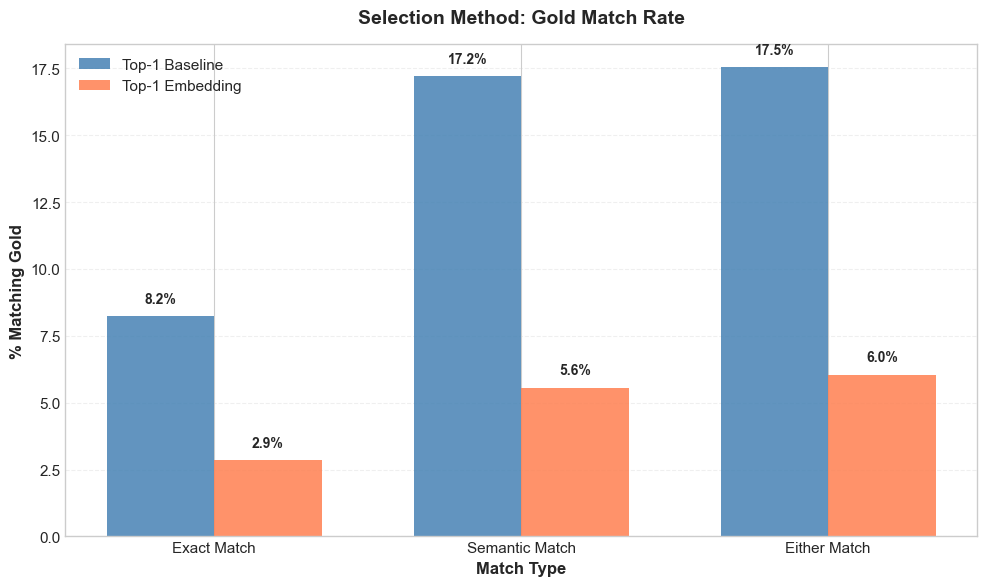

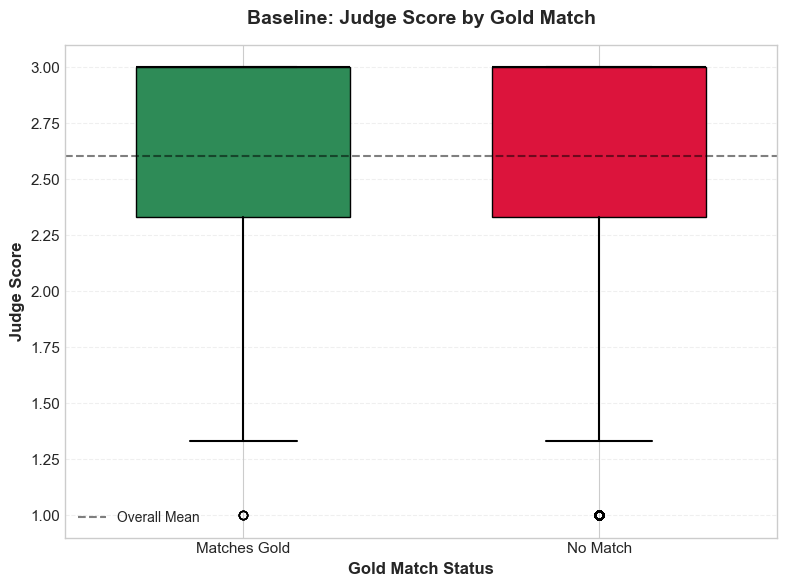

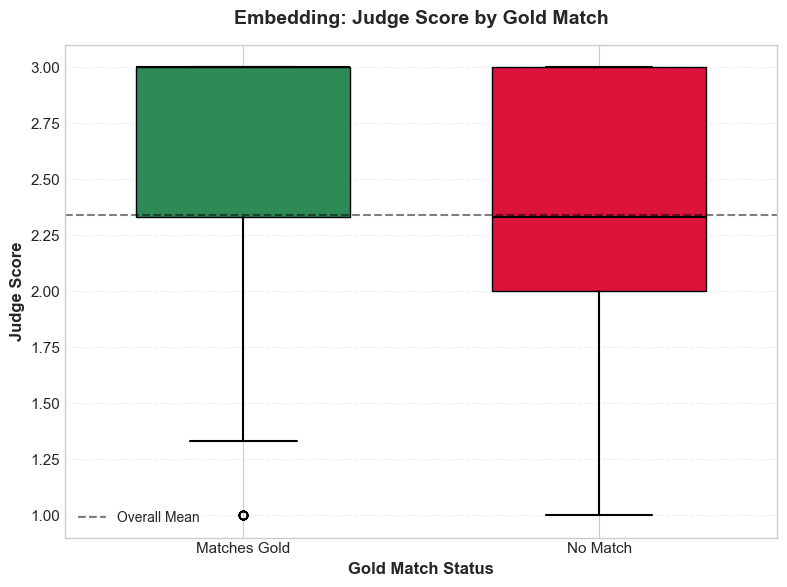

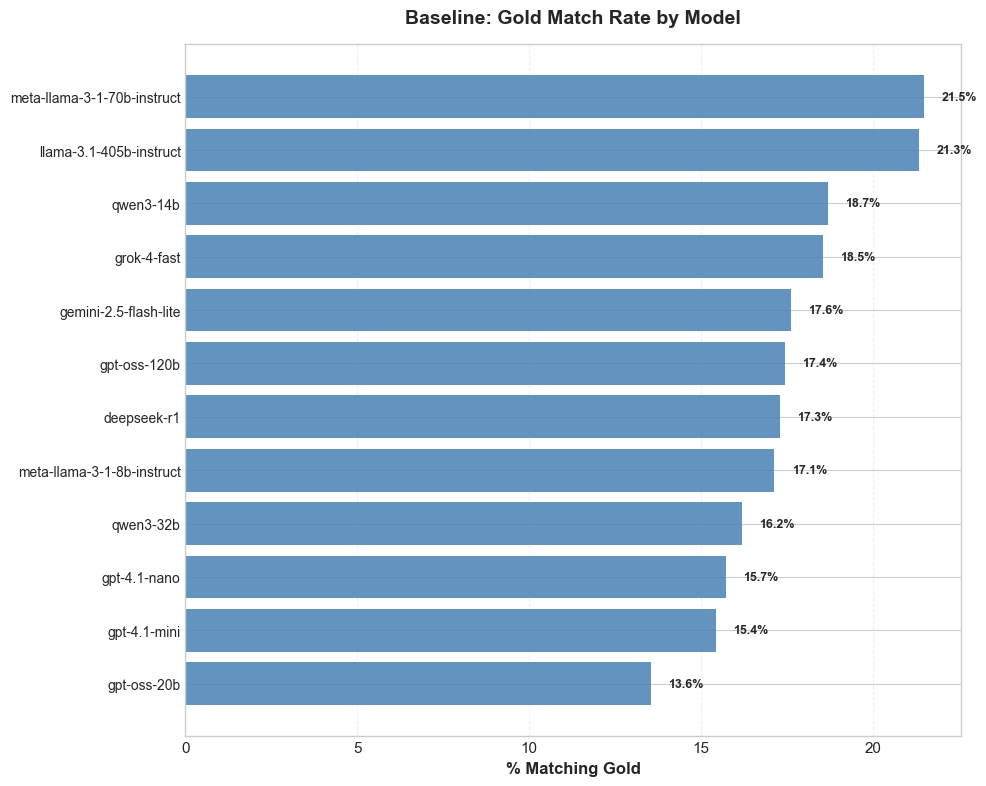

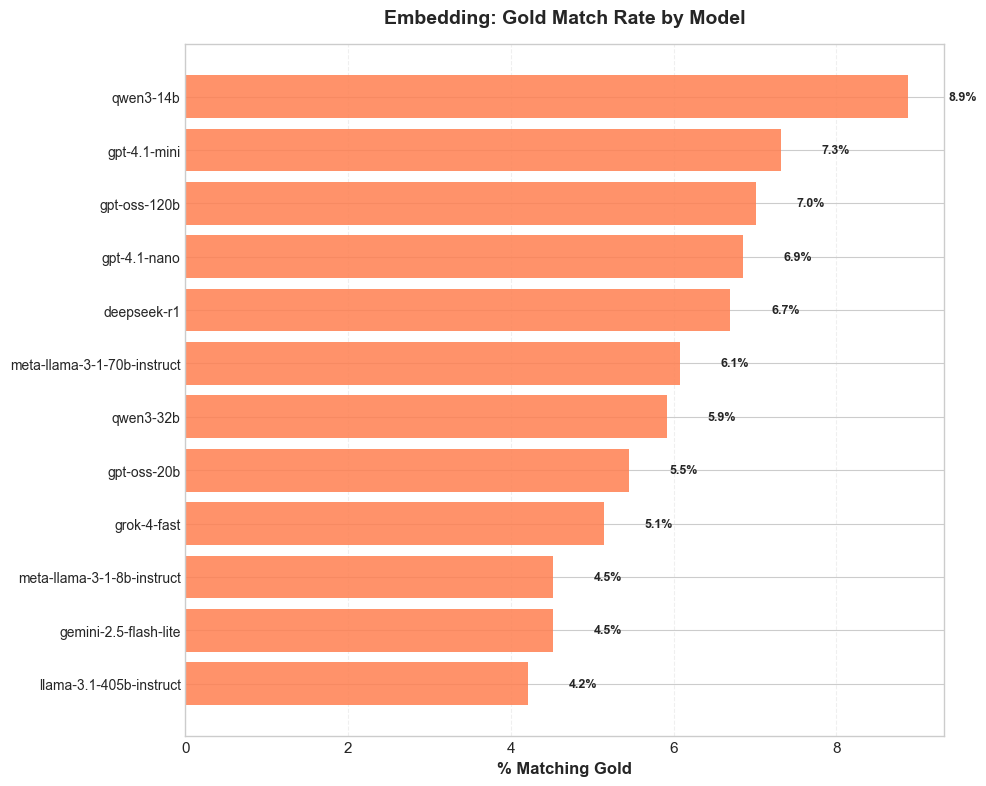

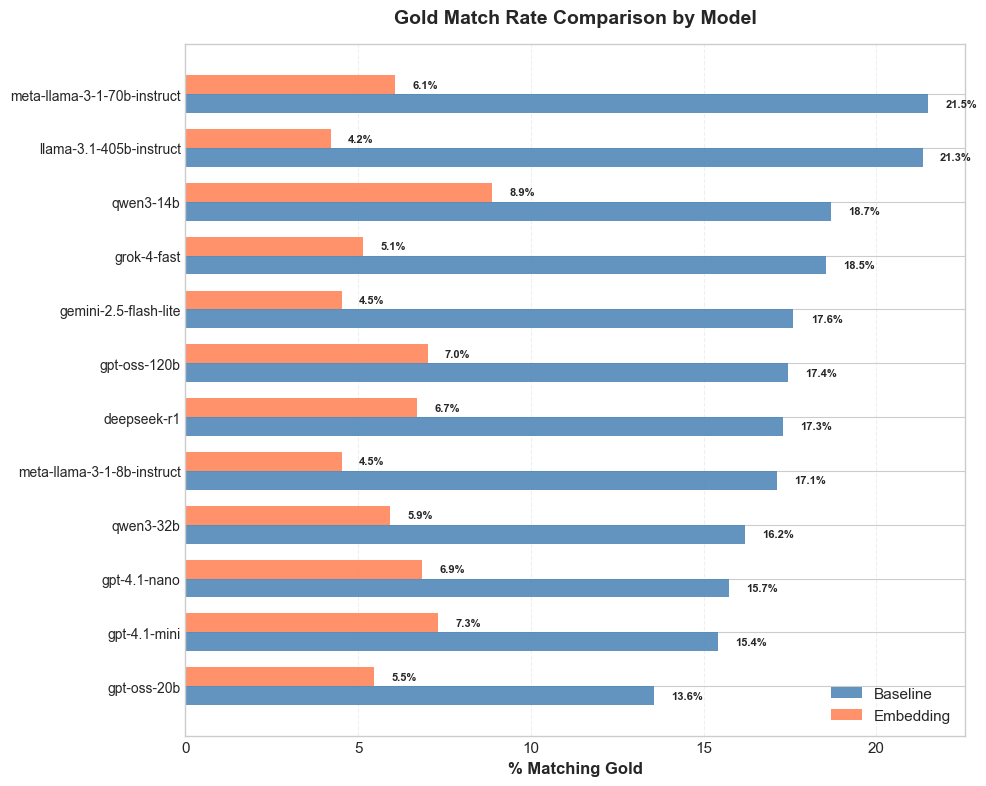


--------------------------------------------------------------------------------
MODEL RANKING: Combined Gold Match Rate + Judge Score
--------------------------------------------------------------------------------

                             Baseline_Gold%  Embedding_Gold%  Baseline_Judge  Embedding_Judge  Baseline_Combined  Embedding_Combined
model                                                                                                                               
llama-3.1-405b-instruct                21.3              4.2           2.639            2.390             103.25               73.70
gemini-2.5-flash-lite                  17.6              4.5           2.681            2.387             101.65               73.85
deepseek-r1                            17.3              6.7           2.686            2.456             101.60               79.50
meta-llama-3-1-70b-instruct            21.5              6.1           2.598            2.372             101.40     

In [46]:
# Cell: Analysis - Do selected analogies (baseline/embedding) match gold standard?
# =============================================================================
# This analysis checks if the analogy selected by each method (baseline or embedding)
# also appears in the Hit@K results (matches a gold source)
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import ast

print("=" * 80)
print("SELECTION METHOD vs GOLD STANDARD ANALYSIS")
print("=" * 80)
print("\nQuestion: Do the selected analogies (baseline/embedding) also match gold sources?")

# =============================================================================
# Helper Functions
# =============================================================================
def safe_parse(x):
    """Parse JSON or literal string"""
    if pd.isna(x):
        return {}
    try:
        if isinstance(x, dict):
            return x
        return json.loads(x)
    except:
        try:
            return ast.literal_eval(x)
        except:
            return {}

def safe_parse_list(x):
    """Parse list from string"""
    if pd.isna(x):
        return []
    try:
        if isinstance(x, list):
            return x
        return json.loads(x)
    except:
        try:
            return ast.literal_eval(x)
        except:
            return []

# =============================================================================
# Load and Process Data
# =============================================================================
from pathlib import Path
RESULTS_DIR = Path('results')
OUTPUT_DIR = RESULTS_DIR / 'visualizations'
OUTPUT_DIR.mkdir(exist_ok=True)

df_to = pd.read_csv(RESULTS_DIR / 'all_results_targetonly.csv')
df_ws = pd.read_csv(RESULTS_DIR / 'all_results_withsub.csv')
df = pd.concat([df_to, df_ws], ignore_index=True)

# Parse necessary columns
df['generated_analogies_list'] = df['generated_analogies'].apply(safe_parse_list)
df['gold_ranks_dict'] = df['gold_ranks'].apply(safe_parse)
df['sem_gold_ranks_dict'] = df['sem_gold_ranks'].apply(safe_parse)
df['judge_baseline_parsed'] = df['judge_baseline'].apply(safe_parse)
df['judge_embedding_parsed'] = df['judge_embedding'].apply(safe_parse)

# Extract judge averages
df['baseline_judge_avg'] = df['judge_baseline_parsed'].apply(lambda x: x.get('average', np.nan))
df['embedding_judge_avg'] = df['judge_embedding_parsed'].apply(lambda x: x.get('average', np.nan))

# =============================================================================
# Check if top1_baseline (rank 1) matches gold
# =============================================================================
def check_baseline_in_gold(row):
    """Check if rank 1 (top1_baseline) appears in gold_ranks (exact match)"""
    gold_ranks = row['gold_ranks_dict']
    if not gold_ranks:
        return False
    return 1 in gold_ranks.values()

def check_baseline_in_gold_sem(row):
    """Check if rank 1 (top1_baseline) appears in sem_gold_ranks (semantic match)"""
    sem_ranks = row['sem_gold_ranks_dict']
    if not sem_ranks:
        return False
    return 1 in sem_ranks.values()

df['baseline_hits_gold_exact'] = df.apply(check_baseline_in_gold, axis=1)
df['baseline_hits_gold_sem'] = df.apply(check_baseline_in_gold_sem, axis=1)
df['baseline_hits_gold_any'] = df['baseline_hits_gold_exact'] | df['baseline_hits_gold_sem']

# =============================================================================
# Check if top1_embedding matches gold
# =============================================================================
def find_embedding_rank(row):
    """Find the rank of top1_embedding in generated_analogies"""
    top1_emb = row['top1_embedding']
    gen_list = row['generated_analogies_list']
    
    if pd.isna(top1_emb) or not gen_list:
        return -1
    
    try:
        # Find position (0-indexed) and convert to rank (1-indexed)
        return gen_list.index(top1_emb) + 1
    except ValueError:
        return -1

df['embedding_rank'] = df.apply(find_embedding_rank, axis=1)

def check_embedding_in_gold(row):
    """Check if embedding_rank appears in gold_ranks (exact match)"""
    emb_rank = row['embedding_rank']
    gold_ranks = row['gold_ranks_dict']
    
    if emb_rank == -1 or not gold_ranks:
        return False
    return emb_rank in gold_ranks.values()

def check_embedding_in_gold_sem(row):
    """Check if embedding_rank appears in sem_gold_ranks (semantic match)"""
    emb_rank = row['embedding_rank']
    sem_ranks = row['sem_gold_ranks_dict']
    
    if emb_rank == -1 or not sem_ranks:
        return False
    return emb_rank in sem_ranks.values()

df['embedding_hits_gold_exact'] = df.apply(check_embedding_in_gold, axis=1)
df['embedding_hits_gold_sem'] = df.apply(check_embedding_in_gold_sem, axis=1)
df['embedding_hits_gold_any'] = df['embedding_hits_gold_exact'] | df['embedding_hits_gold_sem']

# =============================================================================
# Summary Statistics
# =============================================================================
print("\n" + "-" * 80)
print("OVERALL STATISTICS")
print("-" * 80)

total = len(df)
baseline_exact = df['baseline_hits_gold_exact'].sum()
baseline_sem = df['baseline_hits_gold_sem'].sum()
baseline_any = df['baseline_hits_gold_any'].sum()
embedding_exact = df['embedding_hits_gold_exact'].sum()
embedding_sem = df['embedding_hits_gold_sem'].sum()
embedding_any = df['embedding_hits_gold_any'].sum()

print(f"\nTotal records: {total}")
print(f"\nTop-1 BASELINE matches gold:")
print(f"  Exact match:    {baseline_exact:5d} ({baseline_exact/total*100:.2f}%)")
print(f"  Semantic match: {baseline_sem:5d} ({baseline_sem/total*100:.2f}%)")
print(f"  Either match:   {baseline_any:5d} ({baseline_any/total*100:.2f}%)")

print(f"\nTop-1 EMBEDDING matches gold:")
print(f"  Exact match:    {embedding_exact:5d} ({embedding_exact/total*100:.2f}%)")
print(f"  Semantic match: {embedding_sem:5d} ({embedding_sem/total*100:.2f}%)")
print(f"  Either match:   {embedding_any:5d} ({embedding_any/total*100:.2f}%)")

# =============================================================================
# Judge Score Analysis: Does matching gold = better judge scores?
# =============================================================================
print("\n" + "-" * 80)
print("JUDGE SCORES: Matching Gold vs Not Matching")
print("-" * 80)

# Baseline
baseline_match_judge = df[df['baseline_hits_gold_any']]['baseline_judge_avg'].mean()
baseline_no_match_judge = df[~df['baseline_hits_gold_any']]['baseline_judge_avg'].mean()
print(f"\nBaseline selection:")
print(f"  When matches gold: {baseline_match_judge:.3f} (n={df['baseline_hits_gold_any'].sum()})")
print(f"  When no match:     {baseline_no_match_judge:.3f} (n={(~df['baseline_hits_gold_any']).sum()})")

# Embedding
embedding_match_judge = df[df['embedding_hits_gold_any']]['embedding_judge_avg'].mean()
embedding_no_match_judge = df[~df['embedding_hits_gold_any']]['embedding_judge_avg'].mean()
print(f"\nEmbedding selection:")
print(f"  When matches gold: {embedding_match_judge:.3f} (n={df['embedding_hits_gold_any'].sum()})")
print(f"  When no match:     {embedding_no_match_judge:.3f} (n={(~df['embedding_hits_gold_any']).sum()})")

# =============================================================================
# VISUALIZATION - Individual Figures
# =============================================================================
COLORS = {
    'primary': '#4682B4',      # Steel Blue
    'secondary': '#FF7F50',    # Coral Orange
    'accent1': '#5A9BD4',      # Light Steel Blue
    'accent2': '#FF9966',      # Light Coral
    'dark': '#2F5496',         # Dark Steel Blue
    'success': '#2E8B57',      # Sea Green
    'fail': '#DC143C',         # Crimson
}

# --- Figure 1: Hit Rate Comparison (Bar Chart) ---
fig1, ax1 = plt.subplots(figsize=(10, 6))
categories = ['Exact Match', 'Semantic Match', 'Either Match']
baseline_rates = [baseline_exact/total*100, baseline_sem/total*100, baseline_any/total*100]
embedding_rates = [embedding_exact/total*100, embedding_sem/total*100, embedding_any/total*100]

x = np.arange(len(categories))
width = 0.35

ax1.bar(x - width/2, baseline_rates, width, label='Top-1 Baseline', color=COLORS['primary'], alpha=0.85)
ax1.bar(x + width/2, embedding_rates, width, label='Top-1 Embedding', color=COLORS['secondary'], alpha=0.85)
ax1.set_ylabel('% Matching Gold', fontsize=12, fontweight='bold')
ax1.set_xlabel('Match Type', fontsize=12, fontweight='bold')
ax1.set_title('Selection Method: Gold Match Rate', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=11)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (b, e) in enumerate(zip(baseline_rates, embedding_rates)):
    ax1.text(i - width/2, b + 0.5, f'{b:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax1.text(i + width/2, e + 0.5, f'{e:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_selection_vs_gold_1_match_rate.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# --- Figure 2: Judge Scores by Gold Match Status (Baseline) ---
fig2, ax2 = plt.subplots(figsize=(8, 6))
data_baseline = [
    df[df['baseline_hits_gold_any']]['baseline_judge_avg'].dropna(),
    df[~df['baseline_hits_gold_any']]['baseline_judge_avg'].dropna()
]
bp1 = ax2.boxplot(data_baseline, labels=['Matches Gold', 'No Match'], patch_artist=True, widths=0.6)
bp1['boxes'][0].set_facecolor(COLORS['success'])
bp1['boxes'][1].set_facecolor(COLORS['fail'])
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    for patch in bp1[element]:
        patch.set_color('black')
        patch.set_linewidth(1.5)

ax2.set_ylabel('Judge Score', fontsize=12, fontweight='bold')
ax2.set_xlabel('Gold Match Status', fontsize=12, fontweight='bold')
ax2.set_title('Baseline: Judge Score by Gold Match', fontsize=14, fontweight='bold', pad=15)
ax2.axhline(y=df['baseline_judge_avg'].mean(), color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Overall Mean')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_selection_vs_gold_2_baseline_judge.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# --- Figure 3: Judge Scores by Gold Match Status (Embedding) ---
fig3, ax3 = plt.subplots(figsize=(8, 6))
data_embedding = [
    df[df['embedding_hits_gold_any']]['embedding_judge_avg'].dropna(),
    df[~df['embedding_hits_gold_any']]['embedding_judge_avg'].dropna()
]
bp2 = ax3.boxplot(data_embedding, labels=['Matches Gold', 'No Match'], patch_artist=True, widths=0.6)
bp2['boxes'][0].set_facecolor(COLORS['success'])
bp2['boxes'][1].set_facecolor(COLORS['fail'])
for element in ['whiskers', 'fliers', 'means', 'medians', 'caps']:
    for patch in bp2[element]:
        patch.set_color('black')
        patch.set_linewidth(1.5)

ax3.set_ylabel('Judge Score', fontsize=12, fontweight='bold')
ax3.set_xlabel('Gold Match Status', fontsize=12, fontweight='bold')
ax3.set_title('Embedding: Judge Score by Gold Match', fontsize=14, fontweight='bold', pad=15)
ax3.axhline(y=df['embedding_judge_avg'].mean(), color='black', linestyle='--', alpha=0.5, linewidth=1.5, label='Overall Mean')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_selection_vs_gold_3_embedding_judge.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# --- Figure 4: By Model - Baseline Gold Match Rate ---
fig4, ax4 = plt.subplots(figsize=(10, 8))
model_baseline_match = df.groupby('model')['baseline_hits_gold_any'].mean() * 100
model_baseline_match = model_baseline_match.sort_values(ascending=True)
ax4.barh(range(len(model_baseline_match)), model_baseline_match.values, color=COLORS['primary'], alpha=0.85)
ax4.set_yticks(range(len(model_baseline_match)))
ax4.set_yticklabels(model_baseline_match.index, fontsize=10)
ax4.set_xlabel('% Matching Gold', fontsize=12, fontweight='bold')
ax4.set_title('Baseline: Gold Match Rate by Model', fontsize=14, fontweight='bold', pad=15)
ax4.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, val in enumerate(model_baseline_match.values):
    ax4.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_selection_vs_gold_4_baseline_by_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# --- Figure 5: By Model - Embedding Gold Match Rate ---
fig5, ax5 = plt.subplots(figsize=(10, 8))
model_embedding_match = df.groupby('model')['embedding_hits_gold_any'].mean() * 100
model_embedding_match = model_embedding_match.sort_values(ascending=True)
ax5.barh(range(len(model_embedding_match)), model_embedding_match.values, color=COLORS['secondary'], alpha=0.85)
ax5.set_yticks(range(len(model_embedding_match)))
ax5.set_yticklabels(model_embedding_match.index, fontsize=10)
ax5.set_xlabel('% Matching Gold', fontsize=12, fontweight='bold')
ax5.set_title('Embedding: Gold Match Rate by Model', fontsize=14, fontweight='bold', pad=15)
ax5.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, val in enumerate(model_embedding_match.values):
    ax5.text(val + 0.5, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_selection_vs_gold_5_embedding_by_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# --- Figure 6: Combined - Gold Match Rate Comparison by Model ---
fig6, ax6 = plt.subplots(figsize=(10, 8))
model_order = model_baseline_match.index
x = np.arange(len(model_order))
width = 0.35

baseline_vals = [model_baseline_match[m] for m in model_order]
embedding_vals = [model_embedding_match[m] for m in model_order]

ax6.barh(x - width/2, baseline_vals, width, label='Baseline', color=COLORS['primary'], alpha=0.85)
ax6.barh(x + width/2, embedding_vals, width, label='Embedding', color=COLORS['secondary'], alpha=0.85)
ax6.set_yticks(x)
ax6.set_yticklabels(model_order, fontsize=10)
ax6.set_xlabel('% Matching Gold', fontsize=12, fontweight='bold')
ax6.set_title('Gold Match Rate Comparison by Model', fontsize=14, fontweight='bold', pad=15)
ax6.legend(fontsize=11, loc='lower right')
ax6.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (b, e) in enumerate(zip(baseline_vals, embedding_vals)):
    ax6.text(b + 0.5, i - width/2, f'{b:.1f}%', va='center', fontsize=8, fontweight='bold')
    ax6.text(e + 0.5, i + width/2, f'{e:.1f}%', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_selection_vs_gold_6_comparison_by_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# Summary Table: Model Ranking by Gold Match + Judge Score
# =============================================================================
print("\n" + "-" * 80)
print("MODEL RANKING: Combined Gold Match Rate + Judge Score")
print("-" * 80)

model_summary = df.groupby('model').agg({
    'baseline_hits_gold_any': 'mean',
    'embedding_hits_gold_any': 'mean',
    'baseline_judge_avg': 'mean',
    'embedding_judge_avg': 'mean'
}).round(3)

model_summary.columns = ['Baseline_Gold%', 'Embedding_Gold%', 'Baseline_Judge', 'Embedding_Judge']
model_summary['Baseline_Gold%'] *= 100
model_summary['Embedding_Gold%'] *= 100

# Compute combined score (gold match rate + normalized judge score)
model_summary['Baseline_Combined'] = model_summary['Baseline_Gold%'] + ((model_summary['Baseline_Judge'] - 1) / 2 * 100)
model_summary['Embedding_Combined'] = model_summary['Embedding_Gold%'] + ((model_summary['Embedding_Judge'] - 1) / 2 * 100)

print("\n" + model_summary.sort_values('Baseline_Combined', ascending=False).to_string())

# =============================================================================
# CONCLUSION
# =============================================================================
print("\n" + "=" * 80)
print("CONCLUSIONS")
print("=" * 80)

better_gold = "BASELINE" if baseline_any > embedding_any else "EMBEDDING"
better_judge_match = "BASELINE" if baseline_match_judge > embedding_match_judge else "EMBEDDING"

print(f"\n1. Gold Match Rate: {better_gold} selection more often picks analogies that match gold")
print(f"   - Baseline: {baseline_any/total*100:.2f}%")
print(f"   - Embedding: {embedding_any/total*100:.2f}%")

print(f"\n2. When matching gold, {better_judge_match} has higher judge scores")
print(f"   - Baseline (when matches): {baseline_match_judge:.3f}")
print(f"   - Embedding (when matches): {embedding_match_judge:.3f}")

print(f"\n3. Overall recommendation for choosing analogies:")
if baseline_any > embedding_any and baseline_match_judge >= embedding_match_judge:
    print("   → Use BASELINE (top-1 from LLM) - better gold match AND quality")
elif embedding_any > baseline_any and embedding_match_judge >= baseline_match_judge:
    print("   → Use EMBEDDING (similarity-based) - better gold match AND quality")
else:
    print("   → Mixed results - consider task requirements:")
    print(f"     - For gold alignment: {better_gold}")
    print(f"     - For quality when aligned: {better_judge_match}")

print(f"\n💾 All 6 figures saved to: {OUTPUT_DIR}/")
print("   - figure_selection_vs_gold_1_match_rate.png")
print("   - figure_selection_vs_gold_2_baseline_judge.png")
print("   - figure_selection_vs_gold_3_embedding_judge.png")
print("   - figure_selection_vs_gold_4_baseline_by_model.png")
print("   - figure_selection_vs_gold_5_embedding_by_model.png")
print("   - figure_selection_vs_gold_6_comparison_by_model.png")

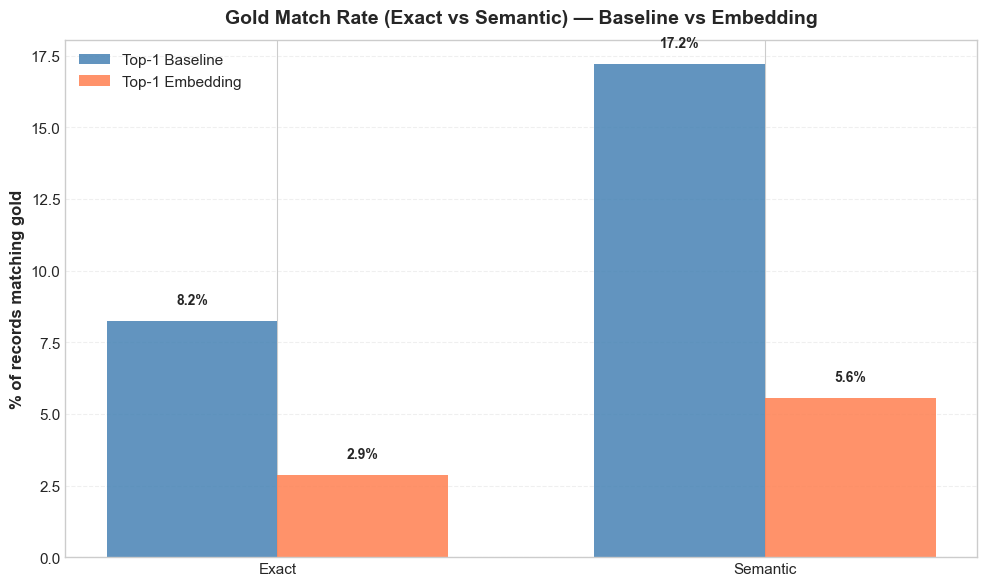

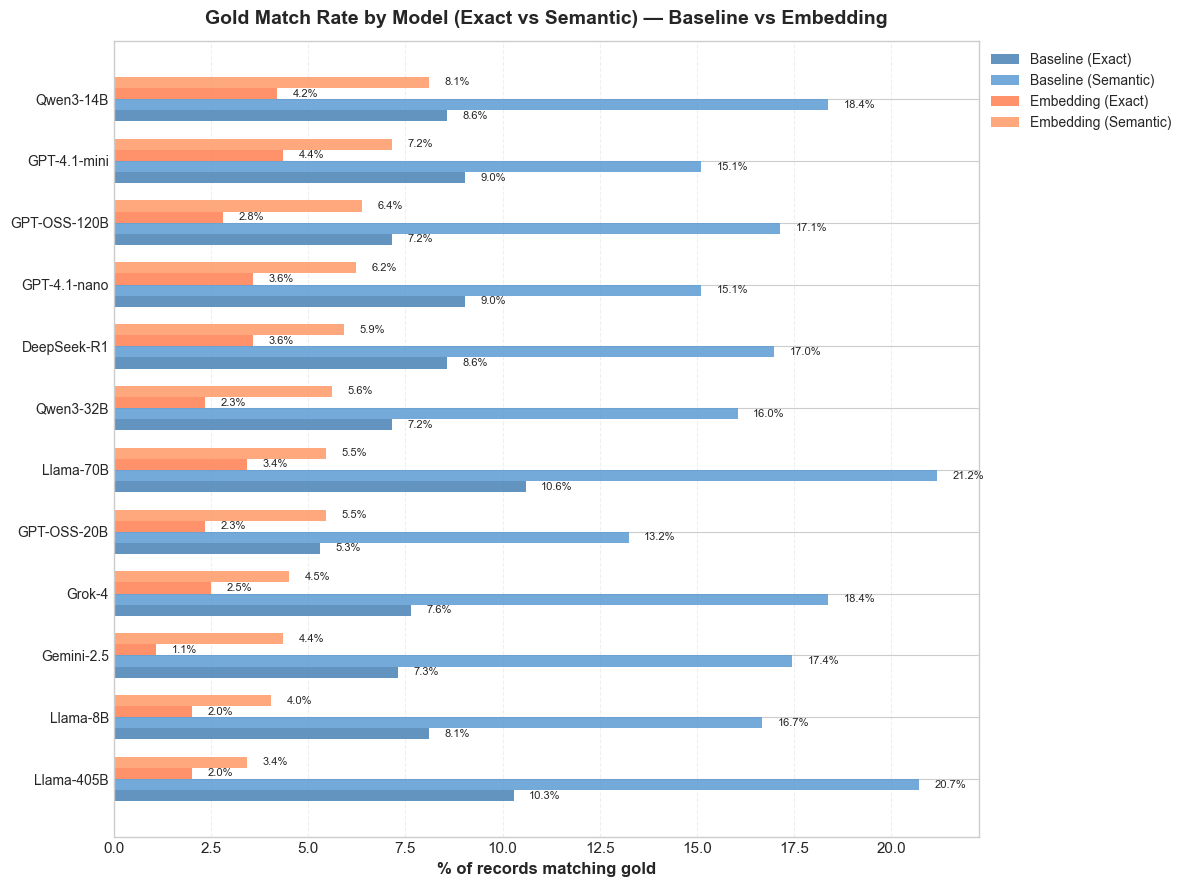

In [ ]:
# Add this AFTER you compute:
# baseline_hits_gold_exact / baseline_hits_gold_sem
# embedding_hits_gold_exact / embedding_hits_gold_sem

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path('results')
OUTPUT_DIR = RESULTS_DIR / 'visualizations'
OUTPUT_DIR.mkdir(exist_ok=True)

# Thesis-ish colors
COLORS = {
    'primary': '#4682B4',      # Steel Blue
    'secondary': '#FF7F50',    # Coral Orange
    'accent1': '#5A9BD4',      # Light Steel Blue
    'accent2': '#FF9966',      # Light Coral
    'dark': '#2F5496',         # Dark Steel Blue
    'success': '#2E8B57',      # Sea Green
    'fail': '#DC143C',         # Crimson
}

def model_label(m):
    # If you already have get_model_abbrev(model), use it instead:
    try:
        return get_model_abbrev(m)  # noqa
    except NameError:
        return m

# =============================================================================
# FIGURE A (Overall): Exact vs Semantic — Baseline vs Embedding (same plot)
# =============================================================================
total = len(df)

baseline_exact_rate = df['baseline_hits_gold_exact'].mean() * 100
baseline_sem_rate   = df['baseline_hits_gold_sem'].mean() * 100
embed_exact_rate    = df['embedding_hits_gold_exact'].mean() * 100
embed_sem_rate      = df['embedding_hits_gold_sem'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 6))

groups = ['Exact', 'Semantic']
x = np.arange(len(groups))
width = 0.35

baseline_rates = [baseline_exact_rate, baseline_sem_rate]
embed_rates    = [embed_exact_rate, embed_sem_rate]

ax.bar(x - width/2, baseline_rates, width, label='Top-1 Baseline', color=COLORS['primary'], alpha=0.85)
ax.bar(x + width/2, embed_rates,    width, label='Top-1 Embedding', color=COLORS['secondary'], alpha=0.85)

ax.set_title('Gold Match Rate (Exact vs Semantic) — Baseline vs Embedding', fontweight='bold', pad=12)
ax.set_ylabel('% of records matching gold', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper left')

for i, (b, e) in enumerate(zip(baseline_rates, embed_rates)):
    ax.text(i - width/2, b + 0.6, f'{b:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + width/2, e + 0.6, f'{e:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_selection_vs_gold_overall_exact_vs_sem.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# FIGURE B (By model): Exact vs Semantic — Baseline vs Embedding (same plot)
#   4 bars per model: baseline-exact, baseline-sem, embedding-exact, embedding-sem
# =============================================================================
by_model = df.groupby('model').agg(
    baseline_exact=('baseline_hits_gold_exact', 'mean'),
    baseline_sem=('baseline_hits_gold_sem', 'mean'),
    embed_exact=('embedding_hits_gold_exact', 'mean'),
    embed_sem=('embedding_hits_gold_sem', 'mean'),
).fillna(0.0) * 100

# pick ordering (semantic embedding as a sensible default); change if you want
by_model = by_model.sort_values('embed_sem', ascending=True)

models = by_model.index.tolist()
y = np.arange(len(models))

fig, ax = plt.subplots(figsize=(12, 9))

h = 0.18  # bar height
ax.barh(y - 1.5*h, by_model['baseline_exact'], height=h, color=COLORS['primary'],  alpha=0.85, label='Baseline (Exact)')
ax.barh(y - 0.5*h, by_model['baseline_sem'],   height=h, color=COLORS['accent1'], alpha=0.85, label='Baseline (Semantic)')
ax.barh(y + 0.5*h, by_model['embed_exact'],    height=h, color=COLORS['secondary'], alpha=0.85, label='Embedding (Exact)')
ax.barh(y + 1.5*h, by_model['embed_sem'],      height=h, color=COLORS['accent2'], alpha=0.85, label='Embedding (Semantic)')

ax.set_yticks(y)
ax.set_yticklabels([model_label(m) for m in models], fontsize=10)
ax.set_xlabel('% of records matching gold', fontweight='bold')
ax.set_title('Gold Match Rate by Model (Exact vs Semantic) — Baseline vs Embedding', fontweight='bold', pad=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10, framealpha=0.95)

plt.tight_layout()
# value labels (optional; comment out if too crowded)
for i, m in enumerate(models):
    ax.text(by_model.loc[m, 'baseline_exact'] + 0.4, i - 1.5*h, f"{by_model.loc[m,'baseline_exact']:.1f}%", va='center', fontsize=8)
    ax.text(by_model.loc[m, 'baseline_sem']   + 0.4, i - 0.5*h, f"{by_model.loc[m,'baseline_sem']:.1f}%", va='center', fontsize=8)
    ax.text(by_model.loc[m, 'embed_exact']    + 0.4, i + 0.5*h, f"{by_model.loc[m,'embed_exact']:.1f}%", va='center', fontsize=8)
    ax.text(by_model.loc[m, 'embed_sem']      + 0.4, i + 1.5*h, f"{by_model.loc[m,'embed_sem']:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_selection_vs_gold_by_model_exact_vs_sem.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## Target only VS with Subconcepts

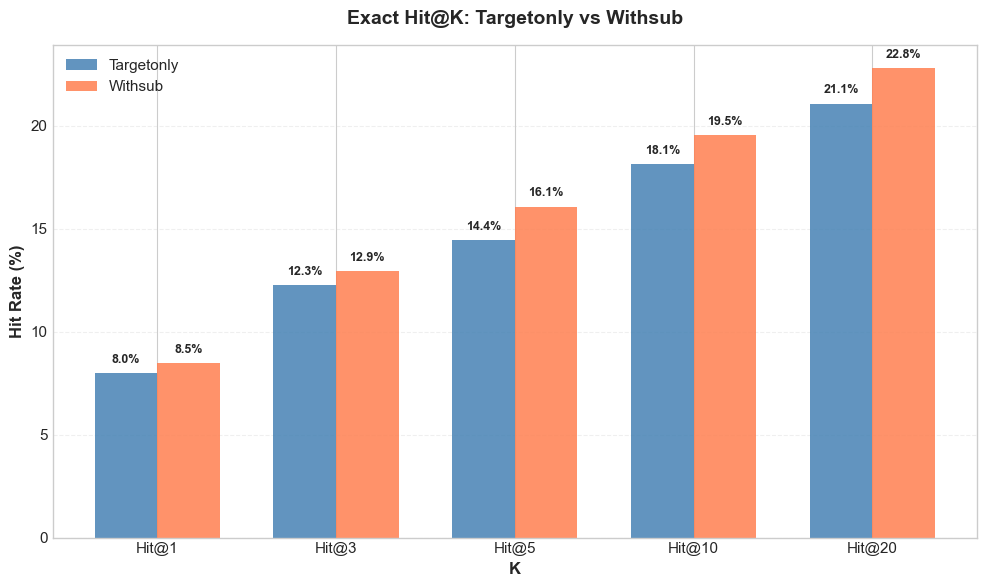

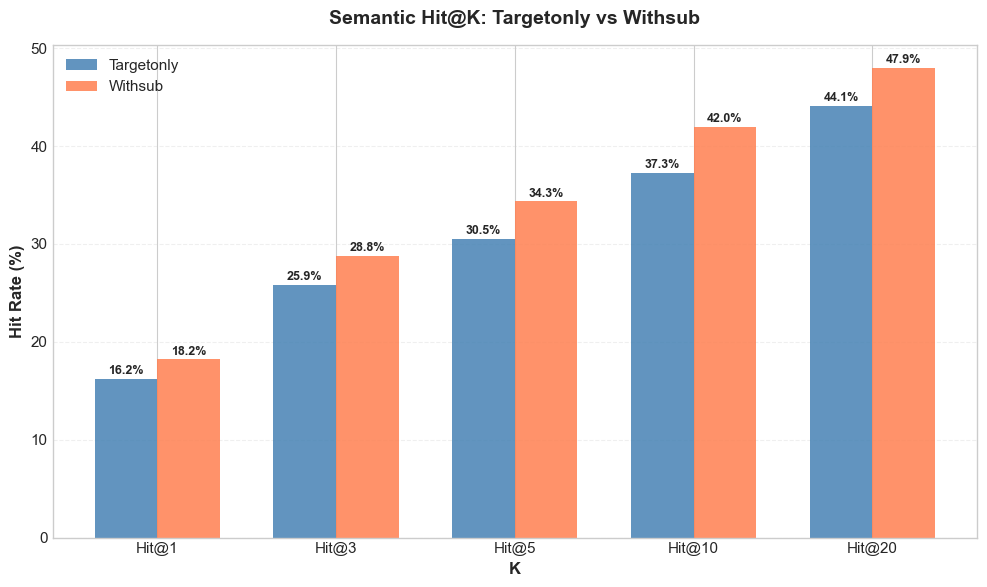

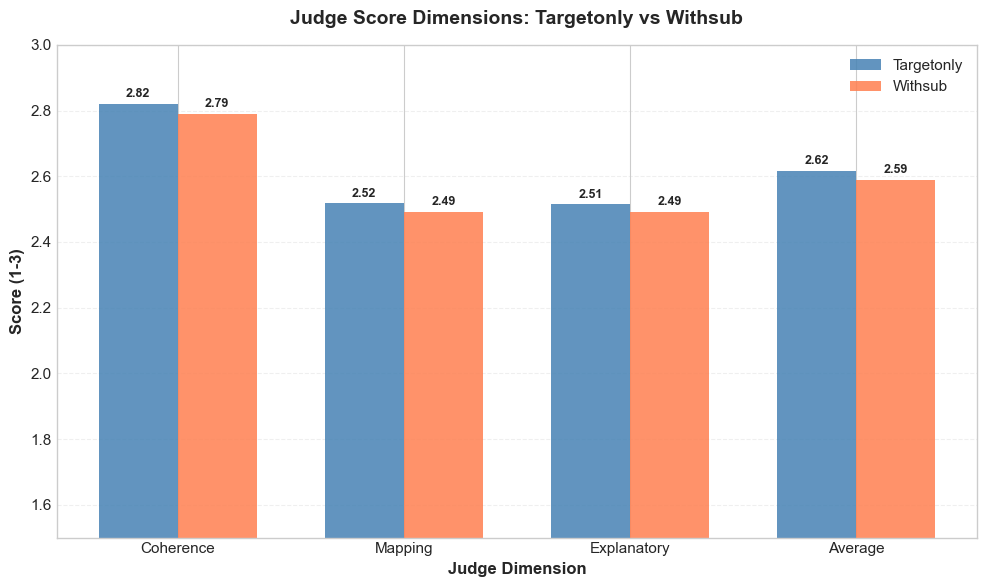

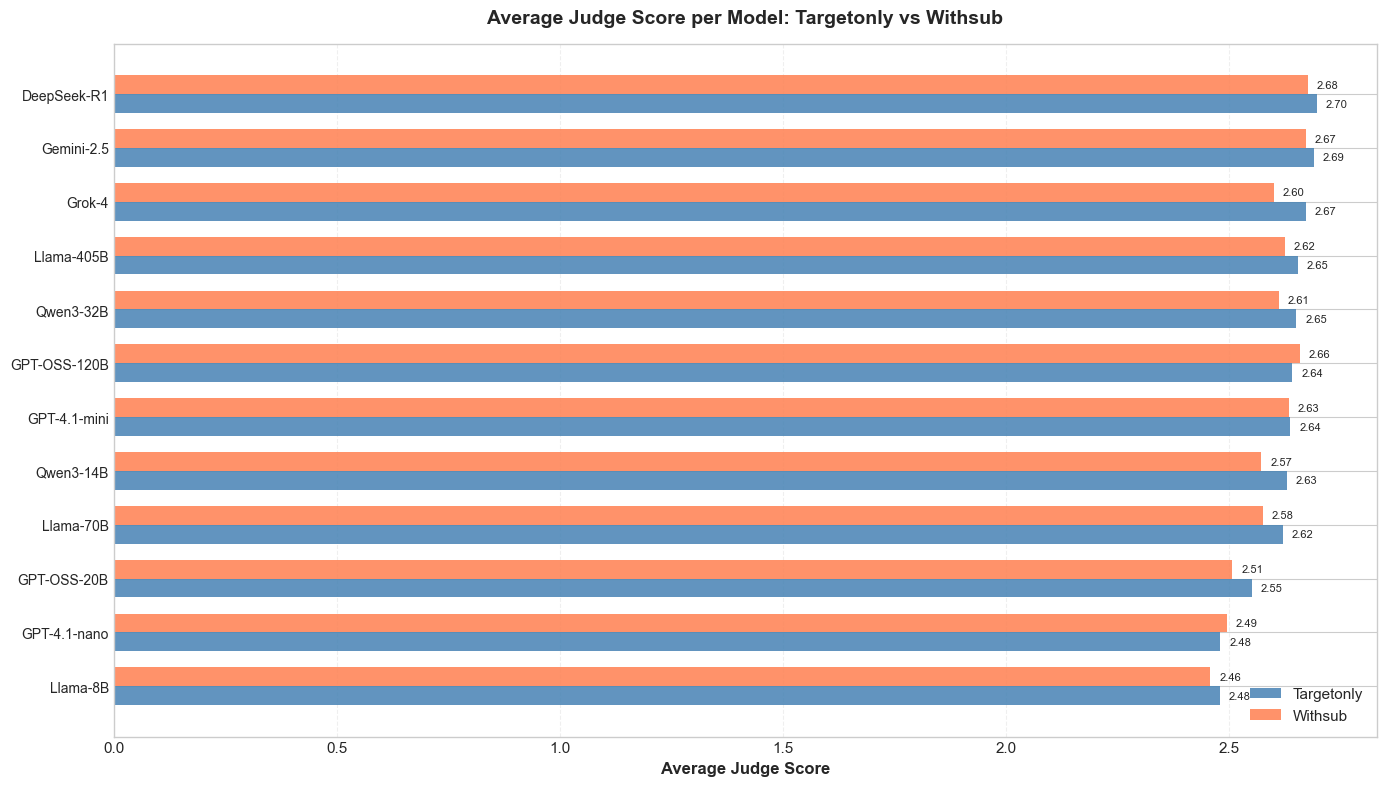

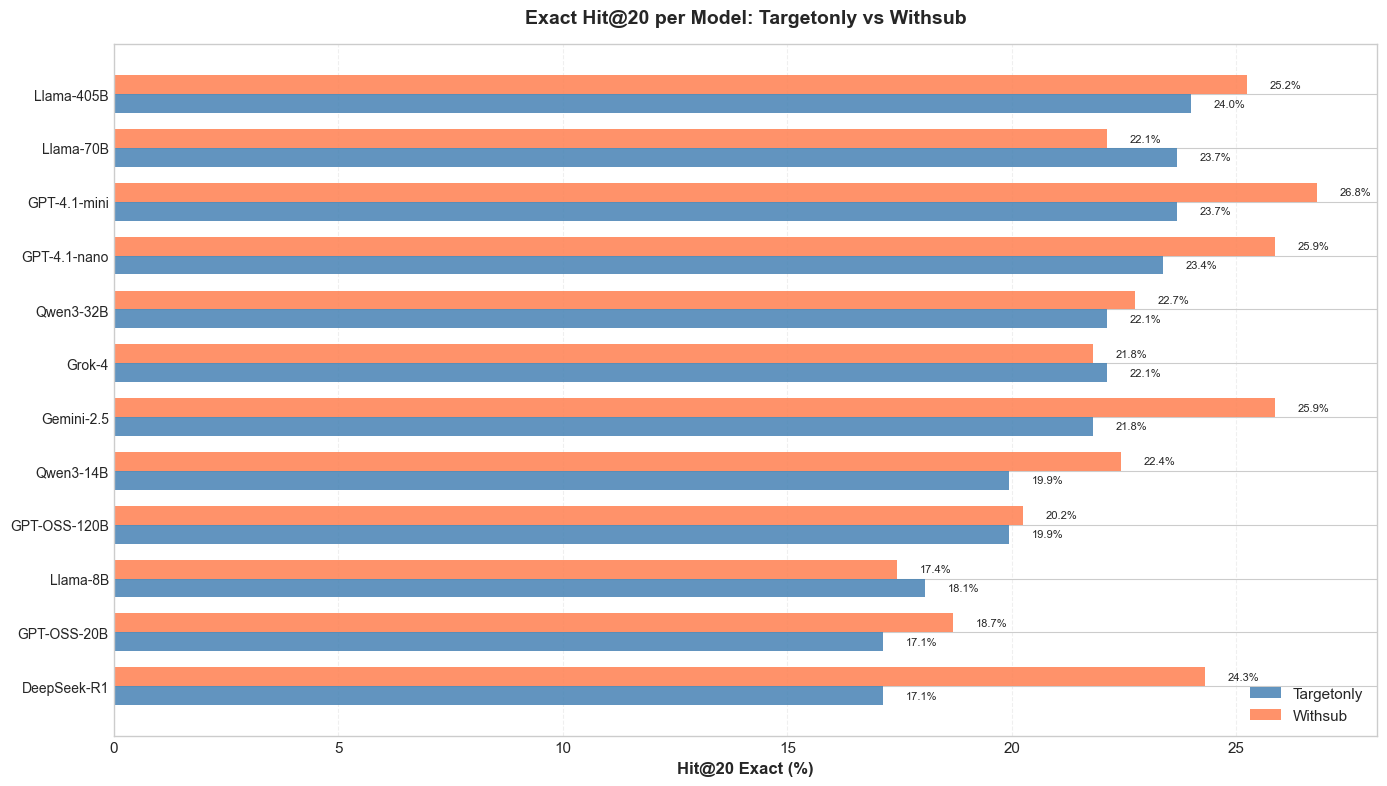

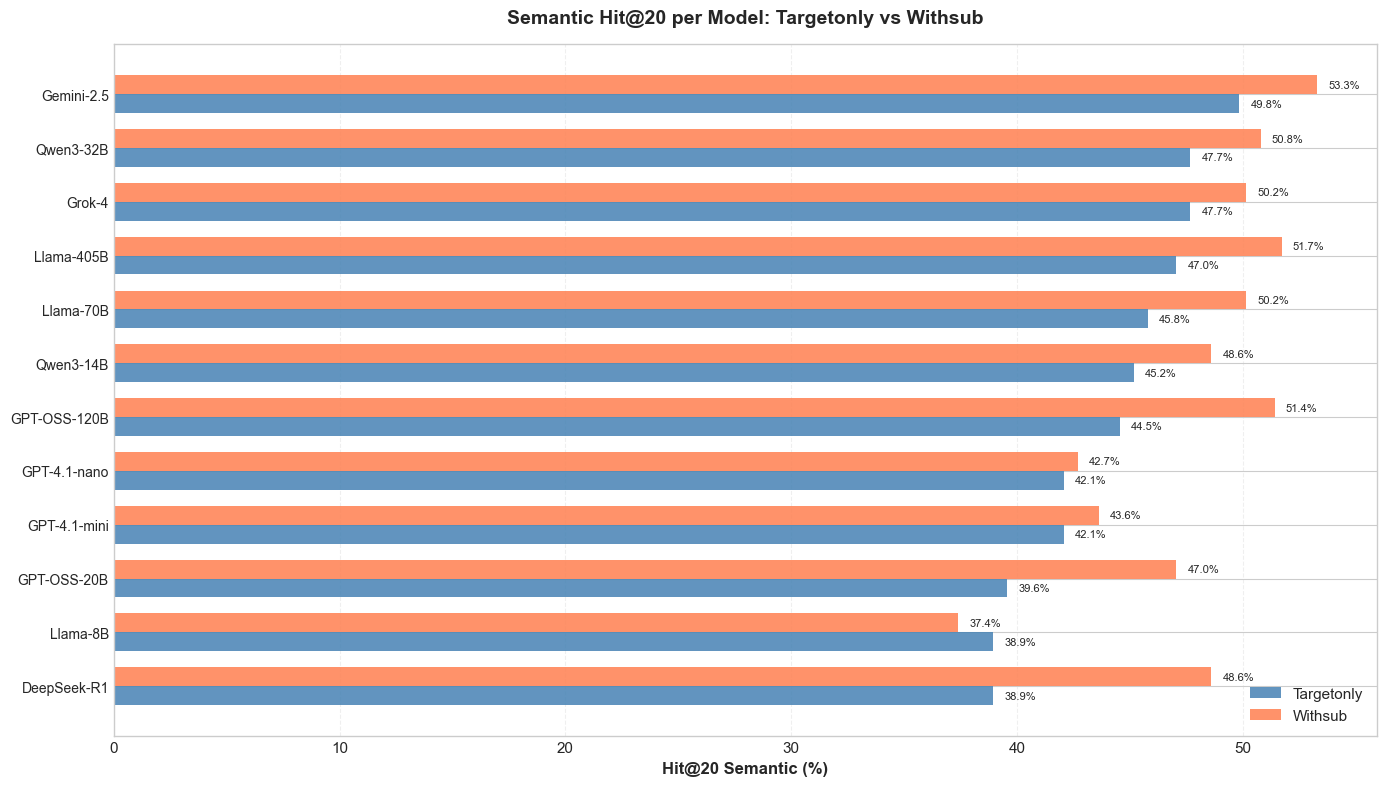


SUMMARY: Targetonly vs Withsub

Overall Hit@K:
------------------------------------------------------------
  Hit@ 1 Exact:    Targetonly=  8.0%  Withsub=  8.5%  Diff= -0.5%
  Hit@ 1 Semantic: Targetonly= 16.2%  Withsub= 18.2%  Diff= -2.0%
  Hit@ 3 Exact:    Targetonly= 12.3%  Withsub= 12.9%  Diff= -0.7%
  Hit@ 3 Semantic: Targetonly= 25.9%  Withsub= 28.8%  Diff= -3.0%
  Hit@ 5 Exact:    Targetonly= 14.4%  Withsub= 16.1%  Diff= -1.6%
  Hit@ 5 Semantic: Targetonly= 30.5%  Withsub= 34.3%  Diff= -3.8%
  Hit@10 Exact:    Targetonly= 18.1%  Withsub= 19.5%  Diff= -1.4%
  Hit@10 Semantic: Targetonly= 37.3%  Withsub= 42.0%  Diff= -4.7%
  Hit@20 Exact:    Targetonly= 21.1%  Withsub= 22.8%  Diff= -1.7%
  Hit@20 Semantic: Targetonly= 44.1%  Withsub= 47.9%  Diff= -3.8%

Overall Judge Scores:
------------------------------------------------------------
  Coherence   : Targetonly=2.820  Withsub=2.790  Diff=+0.030
  Mapping     : Targetonly=2.517  Withsub=2.491  Diff=+0.026
  Explanatory : Targetonl

In [55]:
# =============================================================================
# TARGETONLY vs WITHSUB COMPARISON
# 6 Visualizations comparing the two modes
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

RESULTS_DIR = Path('results')
OUTPUT_DIR = RESULTS_DIR / 'visualizations'
OUTPUT_DIR.mkdir(exist_ok=True)

# Thesis colors
COLORS = {
    'targetonly': '#4682B4',    # Steel Blue
    'withsub': '#FF7F50',       # Coral Orange
}

# Model abbreviations
MODEL_ABBREV = {
    'deepseek-r1': 'DeepSeek-R1',
    'gemini-2.5-flash-lite': 'Gemini-2.5',
    'gpt-4.1-mini': 'GPT-4.1-mini',
    'gpt-4.1-nano': 'GPT-4.1-nano',
    'gpt-oss-120b': 'GPT-OSS-120B',
    'gpt-oss-20b': 'GPT-OSS-20B',
    'grok-4-fast': 'Grok-4',
    'llama-3.1-405b-instruct': 'Llama-405B',
    'meta-llama-3-1-70b-instruct': 'Llama-70B',
    'meta-llama-3-1-8b-instruct': 'Llama-8B',
    'qwen3-14b': 'Qwen3-14B',
    'qwen3-32b': 'Qwen3-32B',
}
def abbrev(m):
    return MODEL_ABBREV.get(m, m)

# =============================================================================
# Ensure columns exist
# =============================================================================
for k in [1, 3, 5, 10, 20]:
    if f'hit_exact_{k}' not in df.columns:
        df[f'hit_exact_{k}'] = ((df['best_exact_rank'] >= 1) & (df['best_exact_rank'] <= k)).astype(int)
    if f'hit_sem_{k}' not in df.columns:
        df[f'hit_sem_{k}'] = ((df['best_sem_rank'] >= 1) & (df['best_sem_rank'] <= k)).astype(int)

def safe_json_parse(x):
    if pd.isna(x): return {}
    try:
        if isinstance(x, dict): return x
        return json.loads(x)
    except: return {}

if 'judge_baseline_parsed' not in df.columns:
    df['judge_baseline_parsed'] = df['judge_baseline'].apply(safe_json_parse)

if 'baseline_coherence' not in df.columns:
    df['baseline_coherence'] = df['judge_baseline_parsed'].apply(lambda x: x.get('coherence', np.nan) if isinstance(x, dict) else np.nan)
if 'baseline_mapping' not in df.columns:
    df['baseline_mapping'] = df['judge_baseline_parsed'].apply(lambda x: x.get('mapping', np.nan) if isinstance(x, dict) else np.nan)
if 'baseline_explanatory' not in df.columns:
    df['baseline_explanatory'] = df['judge_baseline_parsed'].apply(lambda x: x.get('explanatory', np.nan) if isinstance(x, dict) else np.nan)
if 'baseline_judge_avg' not in df.columns:
    df['baseline_judge_avg'] = df['judge_baseline_parsed'].apply(lambda x: x.get('average', np.nan) if isinstance(x, dict) else np.nan)

# =============================================================================
# Aggregate by mode
# =============================================================================
mode_stats = df.groupby('mode').agg({
    'hit_exact_1': 'mean', 'hit_exact_3': 'mean', 'hit_exact_5': 'mean', 
    'hit_exact_10': 'mean', 'hit_exact_20': 'mean',
    'hit_sem_1': 'mean', 'hit_sem_3': 'mean', 'hit_sem_5': 'mean',
    'hit_sem_10': 'mean', 'hit_sem_20': 'mean',
    'baseline_coherence': 'mean', 'baseline_mapping': 'mean',
    'baseline_explanatory': 'mean', 'baseline_judge_avg': 'mean'
}) * 100  # Convert to percentages for hit@k
mode_stats[['baseline_coherence', 'baseline_mapping', 'baseline_explanatory', 'baseline_judge_avg']] = \
    mode_stats[['baseline_coherence', 'baseline_mapping', 'baseline_explanatory', 'baseline_judge_avg']] / 100  # Undo percentage for judge scores

# Aggregate by model and mode
model_mode_stats = df.groupby(['model', 'mode']).agg({
    'hit_exact_20': 'mean', 'hit_sem_20': 'mean', 'baseline_judge_avg': 'mean'
}).reset_index()
model_mode_stats['hit_exact_20'] *= 100
model_mode_stats['hit_sem_20'] *= 100

models = sorted(df['model'].unique())

# =============================================================================
# FIGURE 1: Target vs Subconcept in Exact Hit@K (Overall)
# =============================================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

k_values = [1, 3, 5, 10, 20]
exact_cols = [f'hit_exact_{k}' for k in k_values]

targetonly_exact = [mode_stats.loc['targetonly', col] for col in exact_cols]
withsub_exact = [mode_stats.loc['withsub', col] for col in exact_cols]

x = np.arange(len(k_values))
width = 0.35

ax1.bar(x - width/2, targetonly_exact, width, label='Targetonly', color=COLORS['targetonly'], alpha=0.85)
ax1.bar(x + width/2, withsub_exact, width, label='Withsub', color=COLORS['withsub'], alpha=0.85)

ax1.set_xlabel('K', fontsize=12, fontweight='bold')
ax1.set_ylabel('Hit Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Exact Hit@K: Targetonly vs Withsub', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels([f'Hit@{k}' for k in k_values], fontsize=11)
ax1.legend(fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

for i, (t, w) in enumerate(zip(targetonly_exact, withsub_exact)):
    ax1.text(i - width/2, t + 0.5, f'{t:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax1.text(i + width/2, w + 0.5, f'{w:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_mode_exact_hitk.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# FIGURE 2: Target vs Subconcept in Semantic Hit@K (Overall)
# =============================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

sem_cols = [f'hit_sem_{k}' for k in k_values]

targetonly_sem = [mode_stats.loc['targetonly', col] for col in sem_cols]
withsub_sem = [mode_stats.loc['withsub', col] for col in sem_cols]

ax2.bar(x - width/2, targetonly_sem, width, label='Targetonly', color=COLORS['targetonly'], alpha=0.85)
ax2.bar(x + width/2, withsub_sem, width, label='Withsub', color=COLORS['withsub'], alpha=0.85)

ax2.set_xlabel('K', fontsize=12, fontweight='bold')
ax2.set_ylabel('Hit Rate (%)', fontsize=12, fontweight='bold')
ax2.set_title('Semantic Hit@K: Targetonly vs Withsub', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels([f'Hit@{k}' for k in k_values], fontsize=11)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for i, (t, w) in enumerate(zip(targetonly_sem, withsub_sem)):
    ax2.text(i - width/2, t + 0.5, f'{t:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax2.text(i + width/2, w + 0.5, f'{w:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_mode_semantic_hitk.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# FIGURE 3: Target vs Subconcept in Judge Score Dimensions
# =============================================================================
fig3, ax3 = plt.subplots(figsize=(10, 6))

judge_dims = ['Coherence', 'Mapping', 'Explanatory', 'Average']
judge_cols = ['baseline_coherence', 'baseline_mapping', 'baseline_explanatory', 'baseline_judge_avg']

targetonly_judge = [mode_stats.loc['targetonly', col] for col in judge_cols]
withsub_judge = [mode_stats.loc['withsub', col] for col in judge_cols]

x3 = np.arange(len(judge_dims))

ax3.bar(x3 - width/2, targetonly_judge, width, label='Targetonly', color=COLORS['targetonly'], alpha=0.85)
ax3.bar(x3 + width/2, withsub_judge, width, label='Withsub', color=COLORS['withsub'], alpha=0.85)

ax3.set_xlabel('Judge Dimension', fontsize=12, fontweight='bold')
ax3.set_ylabel('Score (1-3)', fontsize=12, fontweight='bold')
ax3.set_title('Judge Score Dimensions: Targetonly vs Withsub', fontsize=14, fontweight='bold', pad=15)
ax3.set_xticks(x3)
ax3.set_xticklabels(judge_dims, fontsize=11)
ax3.legend(fontsize=11)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_ylim(1.5, 3.0)

for i, (t, w) in enumerate(zip(targetonly_judge, withsub_judge)):
    ax3.text(i - width/2, t + 0.02, f'{t:.2f}', ha='center', fontsize=9, fontweight='bold')
    ax3.text(i + width/2, w + 0.02, f'{w:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_mode_judge_dimensions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# FIGURE 4: Target vs Subconcept in Average Judge Score per Model
# =============================================================================
fig4, ax4 = plt.subplots(figsize=(14, 8))

pivot_judge = model_mode_stats.pivot(index='model', columns='mode', values='baseline_judge_avg')
pivot_judge = pivot_judge.sort_values('targetonly', ascending=True)

y = np.arange(len(pivot_judge))
height = 0.35

ax4.barh(y - height/2, pivot_judge['targetonly'], height, label='Targetonly', color=COLORS['targetonly'], alpha=0.85)
ax4.barh(y + height/2, pivot_judge['withsub'], height, label='Withsub', color=COLORS['withsub'], alpha=0.85)

ax4.set_yticks(y)
ax4.set_yticklabels([abbrev(m) for m in pivot_judge.index], fontsize=10)
ax4.set_xlabel('Average Judge Score', fontsize=12, fontweight='bold')
ax4.set_title('Average Judge Score per Model: Targetonly vs Withsub', fontsize=14, fontweight='bold', pad=15)
ax4.legend(loc='lower right', fontsize=11)
ax4.grid(axis='x', alpha=0.3, linestyle='--')

for i, m in enumerate(pivot_judge.index):
    ax4.text(pivot_judge.loc[m, 'targetonly'] + 0.02, i - height/2, f'{pivot_judge.loc[m, "targetonly"]:.2f}', va='center', fontsize=8)
    ax4.text(pivot_judge.loc[m, 'withsub'] + 0.02, i + height/2, f'{pivot_judge.loc[m, "withsub"]:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_mode_judge_per_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# FIGURE 5: Target vs Subconcept in Exact Hit@20 per Model
# =============================================================================
fig5, ax5 = plt.subplots(figsize=(14, 8))

pivot_exact20 = model_mode_stats.pivot(index='model', columns='mode', values='hit_exact_20')
pivot_exact20 = pivot_exact20.sort_values('targetonly', ascending=True)

y5 = np.arange(len(pivot_exact20))

ax5.barh(y5 - height/2, pivot_exact20['targetonly'], height, label='Targetonly', color=COLORS['targetonly'], alpha=0.85)
ax5.barh(y5 + height/2, pivot_exact20['withsub'], height, label='Withsub', color=COLORS['withsub'], alpha=0.85)

ax5.set_yticks(y5)
ax5.set_yticklabels([abbrev(m) for m in pivot_exact20.index], fontsize=10)
ax5.set_xlabel('Hit@20 Exact (%)', fontsize=12, fontweight='bold')
ax5.set_title('Exact Hit@20 per Model: Targetonly vs Withsub', fontsize=14, fontweight='bold', pad=15)
ax5.legend(loc='lower right', fontsize=11)
ax5.grid(axis='x', alpha=0.3, linestyle='--')

for i, m in enumerate(pivot_exact20.index):
    ax5.text(pivot_exact20.loc[m, 'targetonly'] + 0.5, i - height/2, f'{pivot_exact20.loc[m, "targetonly"]:.1f}%', va='center', fontsize=8)
    ax5.text(pivot_exact20.loc[m, 'withsub'] + 0.5, i + height/2, f'{pivot_exact20.loc[m, "withsub"]:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_mode_exact_hit20_per_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# FIGURE 6: Target vs Subconcept in Semantic Hit@20 per Model
# =============================================================================
fig6, ax6 = plt.subplots(figsize=(14, 8))

pivot_sem20 = model_mode_stats.pivot(index='model', columns='mode', values='hit_sem_20')
pivot_sem20 = pivot_sem20.sort_values('targetonly', ascending=True)

y6 = np.arange(len(pivot_sem20))

ax6.barh(y6 - height/2, pivot_sem20['targetonly'], height, label='Targetonly', color=COLORS['targetonly'], alpha=0.85)
ax6.barh(y6 + height/2, pivot_sem20['withsub'], height, label='Withsub', color=COLORS['withsub'], alpha=0.85)

ax6.set_yticks(y6)
ax6.set_yticklabels([abbrev(m) for m in pivot_sem20.index], fontsize=10)
ax6.set_xlabel('Hit@20 Semantic (%)', fontsize=12, fontweight='bold')
ax6.set_title('Semantic Hit@20 per Model: Targetonly vs Withsub', fontsize=14, fontweight='bold', pad=15)
ax6.legend(loc='lower right', fontsize=11)
ax6.grid(axis='x', alpha=0.3, linestyle='--')

for i, m in enumerate(pivot_sem20.index):
    ax6.text(pivot_sem20.loc[m, 'targetonly'] + 0.5, i - height/2, f'{pivot_sem20.loc[m, "targetonly"]:.1f}%', va='center', fontsize=8)
    ax6.text(pivot_sem20.loc[m, 'withsub'] + 0.5, i + height/2, f'{pivot_sem20.loc[m, "withsub"]:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figure_mode_semantic_hit20_per_model.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# =============================================================================
# Summary Statistics
# =============================================================================
print("\n" + "=" * 80)
print("SUMMARY: Targetonly vs Withsub")
print("=" * 80)

print("\nOverall Hit@K:")
print("-" * 60)
for k in k_values:
    t_exact = mode_stats.loc['targetonly', f'hit_exact_{k}']
    w_exact = mode_stats.loc['withsub', f'hit_exact_{k}']
    t_sem = mode_stats.loc['targetonly', f'hit_sem_{k}']
    w_sem = mode_stats.loc['withsub', f'hit_sem_{k}']
    print(f"  Hit@{k:2d} Exact:    Targetonly={t_exact:5.1f}%  Withsub={w_exact:5.1f}%  Diff={t_exact-w_exact:+5.1f}%")
    print(f"  Hit@{k:2d} Semantic: Targetonly={t_sem:5.1f}%  Withsub={w_sem:5.1f}%  Diff={t_sem-w_sem:+5.1f}%")

print("\nOverall Judge Scores:")
print("-" * 60)
for dim, col in zip(judge_dims, judge_cols):
    t_val = mode_stats.loc['targetonly', col]
    w_val = mode_stats.loc['withsub', col]
    print(f"  {dim:12s}: Targetonly={t_val:.3f}  Withsub={w_val:.3f}  Diff={t_val-w_val:+.3f}")

# Count wins per model
targetonly_wins = sum(1 for m in models 
    if pivot_judge.loc[m, 'targetonly'] > pivot_judge.loc[m, 'withsub'])
withsub_wins = len(models) - targetonly_wins

print(f"\nModel-level Judge Score Wins: Targetonly={targetonly_wins}, Withsub={withsub_wins}")

print(f"\n💾 Figures saved to {OUTPUT_DIR}/")
print("   - figure_mode_exact_hitk.png")
print("   - figure_mode_semantic_hitk.png")
print("   - figure_mode_judge_dimensions.png")
print("   - figure_mode_judge_per_model.png")
print("   - figure_mode_exact_hit20_per_model.png")
print("   - figure_mode_semantic_hit20_per_model.png")

In [62]:
import pandas as pd
import json
import numpy as np

def calculate_average_similarity(csv_path):
    """
    Calculate average similarity for top1_baseline and top1_embedding
    using all-mini scores from similarity_per_gold
    """
    df = pd.read_csv(csv_path)
    
    baseline_similarities = []
    embedding_similarities = []
    
    for idx, row in df.iterrows():
        top1_baseline = row['top1_baseline']
        top1_embedding = row['top1_embedding']
        similarity_per_gold_str = row['similarity_per_gold']
        
        # Parse the similarity_per_gold JSON string
        try:
            similarity_per_gold = json.loads(similarity_per_gold_str)
        except:
            # If it's already a dict or empty, handle it
            if isinstance(similarity_per_gold_str, dict):
                similarity_per_gold = similarity_per_gold_str
            else:
                continue
        
        # Collect similarities for top1_baseline across all gold sources
        baseline_scores = []
        embedding_scores = []
        
        for gold_source, gold_data in similarity_per_gold.items():
            if isinstance(gold_data, dict) and 'scores' in gold_data:
                scores = gold_data['scores']
                
                # Get similarity for top1_baseline
                if top1_baseline in scores:
                    baseline_scores.append(scores[top1_baseline])
                
                # Get similarity for top1_embedding
                if top1_embedding in scores:
                    embedding_scores.append(scores[top1_embedding])
        
        # Calculate average for this row
        if baseline_scores:
            baseline_similarities.append(np.mean(baseline_scores))
        else:
            baseline_similarities.append(np.nan)
        
        if embedding_scores:
            embedding_similarities.append(np.mean(embedding_scores))
        else:
            embedding_similarities.append(np.nan)
    
    # Calculate overall averages
    baseline_avg = np.nanmean(baseline_similarities)
    embedding_avg = np.nanmean(embedding_similarities)
    
    return {
        'baseline_avg': baseline_avg,
        'embedding_avg': embedding_avg,
        'baseline_similarities': baseline_similarities,
        'embedding_similarities': embedding_similarities
    }

# Process both files
targetonly_path = r"results\all_results_targetonly.csv"
withsub_path = r"results\all_results_withsub.csv"

print("Processing all_results_targetonly.csv...")
targetonly_results = calculate_average_similarity(targetonly_path)
print(f"Average similarity for top1_baseline: {targetonly_results['baseline_avg']:.4f}")
print(f"Average similarity for top1_embedding: {targetonly_results['embedding_avg']:.4f}")

print("\nProcessing all_results_withsub.csv...")
withsub_results = calculate_average_similarity(withsub_path)
print(f"Average similarity for top1_baseline: {withsub_results['baseline_avg']:.4f}")
print(f"Average similarity for top1_embedding: {withsub_results['embedding_avg']:.4f}")

# Summary
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"\nall_results_targetonly.csv:")
print(f"  Top1 Baseline Average Similarity: {targetonly_results['baseline_avg']:.4f}")
print(f"  Top1 Embedding Average Similarity: {targetonly_results['embedding_avg']:.4f}")

print(f"\nall_results_withsub.csv:")
print(f"  Top1 Baseline Average Similarity: {withsub_results['baseline_avg']:.4f}")
print(f"  Top1 Embedding Average Similarity: {withsub_results['embedding_avg']:.4f}")

Processing all_results_targetonly.csv...


Average similarity for top1_baseline: 0.3053
Average similarity for top1_embedding: 0.2696

Processing all_results_withsub.csv...
Average similarity for top1_baseline: 0.3176
Average similarity for top1_embedding: 0.2617

SUMMARY

all_results_targetonly.csv:
  Top1 Baseline Average Similarity: 0.3053
  Top1 Embedding Average Similarity: 0.2696

all_results_withsub.csv:
  Top1 Baseline Average Similarity: 0.3176
  Top1 Embedding Average Similarity: 0.2617


In [64]:
import pandas as pd
import json
import numpy as np

def calculate_position_average_similarity(csv_path):
    """
    Calculate average similarity for each position (1st, 2nd, ..., 20th)
    of generated analogies with all gold sources
    """
    df = pd.read_csv(csv_path)
    
    # Initialize lists to store similarities for each position (1-20)
    position_similarities = {i: [] for i in range(1, 21)}
    
    for idx, row in df.iterrows():
        # Parse generated analogies
        try:
            generated_analogies = json.loads(row['generated_analogies'])
        except:
            if isinstance(row['generated_analogies'], list):
                generated_analogies = row['generated_analogies']
            else:
                continue
        
        # Parse similarity_per_gold
        try:
            similarity_per_gold = json.loads(row['similarity_per_gold'])
        except:
            if isinstance(row['similarity_per_gold'], dict):
                similarity_per_gold = row['similarity_per_gold']
            else:
                continue
        
        # For each position (1-20)
        for pos in range(1, 21):
            if pos <= len(generated_analogies):
                analogy_at_pos = generated_analogies[pos - 1]  # 0-indexed
                
                # Collect similarities for this analogy across all gold sources
                similarities_for_this_pos = []
                
                for gold_source, gold_data in similarity_per_gold.items():
                    if isinstance(gold_data, dict) and 'scores' in gold_data:
                        scores = gold_data['scores']
                        if analogy_at_pos in scores:
                            similarities_for_this_pos.append(scores[analogy_at_pos])
                
                # Average across all gold sources for this position in this row
                if similarities_for_this_pos:
                    avg_similarity = np.mean(similarities_for_this_pos)
                    position_similarities[pos].append(avg_similarity)
    
    # Calculate average for each position across all rows
    position_averages = {}
    for pos in range(1, 21):
        if position_similarities[pos]:
            position_averages[pos] = np.mean(position_similarities[pos])
        else:
            position_averages[pos] = np.nan
    
    return position_averages, position_similarities

# Process both files
targetonly_path = r"results\all_results_targetonly.csv"
withsub_path = r"results\all_results_withsub.csv"

print("Processing all_results_targetonly.csv...")
targetonly_avg, targetonly_all = calculate_position_average_similarity(targetonly_path)

print("\nProcessing all_results_withsub.csv...")
withsub_avg, withsub_all = calculate_position_average_similarity(withsub_path)

# Display results
print("\n" + "="*80)
print("AVERAGE SIMILARITY BY POSITION")
print("="*80)

print("\nall_results_targetonly.csv:")
print(f"{'Position':<10} {'Average Similarity':<20} {'Count':<10}")
print("-" * 40)
for pos in range(1, 21):
    avg = targetonly_avg[pos]
    count = len(targetonly_all[pos])
    print(f"{pos:<10} {avg:<20.4f} {count:<10}")

print("\nall_results_withsub.csv:")
print(f"{'Position':<10} {'Average Similarity':<20} {'Count':<10}")
print("-" * 40)
for pos in range(1, 21):
    avg = withsub_avg[pos]
    count = len(withsub_all[pos])
    print(f"{pos:<10} {avg:<20.4f} {count:<10}")

# Summary comparison
print("\n" + "="*80)
print("SUMMARY COMPARISON")
print("="*80)
print(f"{'Position':<10} {'TargetOnly Avg':<18} {'WithSub Avg':<18} {'Difference':<15}")
print("-" * 60)
for pos in range(1, 21):
    to_avg = targetonly_avg[pos]
    ws_avg = withsub_avg[pos]
    diff = ws_avg - to_avg if not (np.isnan(to_avg) or np.isnan(ws_avg)) else np.nan
    print(f"{pos:<10} {to_avg:<18.4f} {ws_avg:<18.4f} {diff:<15.4f}")

# Create a DataFrame for easier analysis
results_df = pd.DataFrame({
    'Position': range(1, 21),
    'TargetOnly_Avg': [targetonly_avg[i] for i in range(1, 21)],
    'WithSub_Avg': [withsub_avg[i] for i in range(1, 21)]
})
results_df['Difference'] = results_df['WithSub_Avg'] - results_df['TargetOnly_Avg']

print("\n" + "="*80)
print("Results DataFrame (first 10 rows):")
print("="*80)
print(results_df.head(10).to_string(index=False))

Processing all_results_targetonly.csv...



Processing all_results_withsub.csv...

AVERAGE SIMILARITY BY POSITION

all_results_targetonly.csv:
Position   Average Similarity   Count     
----------------------------------------
1          0.3053               3847      
2          0.2601               3847      
3          0.2483               3847      
4          0.2381               3847      
5          0.2350               3847      
6          0.2283               3847      
7          0.2271               3847      
8          0.2234               3847      
9          0.2221               3847      
10         0.2241               3846      
11         0.2204               3846      
12         0.2171               3846      
13         0.2181               3846      
14         0.2183               3846      
15         0.2144               3846      
16         0.2172               3846      
17         0.2152               3846      
18         0.2133               3844      
19         0.2099               3844      

In [67]:
import pandas as pd
import json
import numpy as np

def calculate_position_average_similarity_with_target(csv_path):
    """
    Calculate average similarity for each position (1st, 2nd, ..., 20th)
    with both target and gold sources
    """
    df = pd.read_csv(csv_path)
    
    # Initialize lists to store similarities for each position (1-20)
    position_target_similarities = {i: [] for i in range(1, 21)}
    position_gold_similarities = {i: [] for i in range(1, 21)}
    
    for idx, row in df.iterrows():
        # Parse generated analogies
        try:
            generated_analogies = json.loads(row['generated_analogies'])
        except:
            if isinstance(row['generated_analogies'], list):
                generated_analogies = row['generated_analogies']
            else:
                continue
        
        # Parse embedding_all_scores (target-to-analogy similarity)
        try:
            embedding_all_scores = json.loads(row['embedding_all_scores'])
        except:
            if isinstance(row['embedding_all_scores'], dict):
                embedding_all_scores = row['embedding_all_scores']
            else:
                embedding_all_scores = {}
        
        # Parse similarity_per_gold (gold-to-analogy similarity)
        try:
            similarity_per_gold = json.loads(row['similarity_per_gold'])
        except:
            if isinstance(row['similarity_per_gold'], dict):
                similarity_per_gold = row['similarity_per_gold']
            else:
                similarity_per_gold = {}
        
        # For each position (1-20)
        for pos in range(1, 21):
            if pos <= len(generated_analogies):
                analogy_at_pos = generated_analogies[pos - 1]  # 0-indexed
                
                # Get target similarity
                if analogy_at_pos in embedding_all_scores:
                    target_sim = embedding_all_scores[analogy_at_pos]
                    position_target_similarities[pos].append(target_sim)
                
                # Collect gold similarities for this analogy across all gold sources
                gold_similarities_for_this_pos = []
                for gold_source, gold_data in similarity_per_gold.items():
                    if isinstance(gold_data, dict) and 'scores' in gold_data:
                        scores = gold_data['scores']
                        if analogy_at_pos in scores:
                            gold_similarities_for_this_pos.append(scores[analogy_at_pos])
                
                # Average across all gold sources for this position in this row
                if gold_similarities_for_this_pos:
                    avg_gold_similarity = np.mean(gold_similarities_for_this_pos)
                    position_gold_similarities[pos].append(avg_gold_similarity)
    
    # Calculate average for each position across all rows
    position_target_averages = {}
    position_gold_averages = {}
    
    for pos in range(1, 21):
        if position_target_similarities[pos]:
            position_target_averages[pos] = np.mean(position_target_similarities[pos])
        else:
            position_target_averages[pos] = np.nan
        
        if position_gold_similarities[pos]:
            position_gold_averages[pos] = np.mean(position_gold_similarities[pos])
        else:
            position_gold_averages[pos] = np.nan
    
    return position_target_averages, position_gold_averages, position_target_similarities, position_gold_similarities

# Process both files
targetonly_path = r"results\all_results_targetonly.csv"
withsub_path = r"results\all_results_withsub.csv"

print("Processing all_results_targetonly.csv...")
to_target_avg, to_gold_avg, to_target_all, to_gold_all = calculate_position_average_similarity_with_target(targetonly_path)

print("\nProcessing all_results_withsub.csv...")
ws_target_avg, ws_gold_avg, ws_target_all, ws_gold_all = calculate_position_average_similarity_with_target(withsub_path)

# Display results
print("\n" + "="*120)
print("AVERAGE SIMILARITY BY POSITION - DETAILED BREAKDOWN")
print("="*120)

print("\nall_results_targetonly.csv:")
print(f"{'Position':<10} {'Target Avg':<15} {'Gold Avg':<15} {'Target-Gold Diff':<18} {'Target Count':<15} {'Gold Count':<15}")
print("-" * 100)
for pos in range(1, 21):
    target_avg = to_target_avg[pos]
    gold_avg = to_gold_avg[pos]
    diff = target_avg - gold_avg if not (np.isnan(target_avg) or np.isnan(gold_avg)) else np.nan
    target_count = len(to_target_all[pos])
    gold_count = len(to_gold_all[pos])
    print(f"{pos:<10} {target_avg:<15.4f} {gold_avg:<15.4f} {diff:<18.4f} {target_count:<15} {gold_count:<15}")

print("\nall_results_withsub.csv:")
print(f"{'Position':<10} {'Target Avg':<15} {'Gold Avg':<15} {'Target-Gold Diff':<18} {'Target Count':<15} {'Gold Count':<15}")
print("-" * 100)
for pos in range(1, 21):
    target_avg = ws_target_avg[pos]
    gold_avg = ws_gold_avg[pos]
    diff = target_avg - gold_avg if not (np.isnan(target_avg) or np.isnan(gold_avg)) else np.nan
    target_count = len(ws_target_all[pos])
    gold_count = len(ws_gold_all[pos])
    print(f"{pos:<10} {target_avg:<15.4f} {gold_avg:<15.4f} {diff:<18.4f} {target_count:<15} {gold_count:<15}")

# COMPARISON: TargetOnly vs WithSub - TARGET SIMILARITY
print("\n" + "="*120)
print("COMPARISON: TargetOnly vs WithSub - TARGET SIMILARITY")
print("="*120)
print(f"{'Position':<10} {'TargetOnly':<15} {'WithSub':<15} {'Difference (WS-TO)':<20} {'% Change':<15}")
print("-" * 80)
for pos in range(1, 21):
    to_val = to_target_avg[pos]
    ws_val = ws_target_avg[pos]
    diff = ws_val - to_val if not (np.isnan(to_val) or np.isnan(ws_val)) else np.nan
    pct_change = (diff / to_val * 100) if not (np.isnan(diff) or np.isnan(to_val) or to_val == 0) else np.nan
    print(f"{pos:<10} {to_val:<15.4f} {ws_val:<15.4f} {diff:<20.4f} {pct_change:<15.2f}%")

# COMPARISON: TargetOnly vs WithSub - GOLD SIMILARITY
print("\n" + "="*120)
print("COMPARISON: TargetOnly vs WithSub - GOLD SIMILARITY")
print("="*120)
print(f"{'Position':<10} {'TargetOnly':<15} {'WithSub':<15} {'Difference (WS-TO)':<20} {'% Change':<15}")
print("-" * 80)
for pos in range(1, 21):
    to_val = to_gold_avg[pos]
    ws_val = ws_gold_avg[pos]
    diff = ws_val - to_val if not (np.isnan(to_val) or np.isnan(ws_val)) else np.nan
    pct_change = (diff / to_val * 100) if not (np.isnan(diff) or np.isnan(to_val) or to_val == 0) else np.nan
    print(f"{pos:<10} {to_val:<15.4f} {ws_val:<15.4f} {diff:<20.4f} {pct_change:<15.2f}%")

# Create comprehensive comparison DataFrame
comparison_df = pd.DataFrame({
    'Position': range(1, 21),
    'TO_Target': [to_target_avg[i] for i in range(1, 21)],
    'TO_Gold': [to_gold_avg[i] for i in range(1, 21)],
    'WS_Target': [ws_target_avg[i] for i in range(1, 21)],
    'WS_Gold': [ws_gold_avg[i] for i in range(1, 21)]
})
comparison_df['TO_Target_Gold_Diff'] = comparison_df['TO_Target'] - comparison_df['TO_Gold']
comparison_df['WS_Target_Gold_Diff'] = comparison_df['WS_Target'] - comparison_df['WS_Gold']
comparison_df['Target_Diff_WS_TO'] = comparison_df['WS_Target'] - comparison_df['TO_Target']
comparison_df['Gold_Diff_WS_TO'] = comparison_df['WS_Gold'] - comparison_df['TO_Gold']

print("\n" + "="*120)
print("COMPREHENSIVE COMPARISON DATAFRAME")
print("="*120)
print(comparison_df.to_string(index=False))

# Overall statistics
print("\n" + "="*120)
print("OVERALL STATISTICS")
print("="*120)

print(f"\nall_results_targetonly.csv:")
to_target_overall = np.nanmean(list(to_target_avg.values()))
to_gold_overall = np.nanmean(list(to_gold_avg.values()))
print(f"  Average Target Similarity (all positions): {to_target_overall:.4f}")
print(f"  Average Gold Similarity (all positions): {to_gold_overall:.4f}")
print(f"  Overall Difference (Target - Gold): {to_target_overall - to_gold_overall:.4f}")

print(f"\nall_results_withsub.csv:")
ws_target_overall = np.nanmean(list(ws_target_avg.values()))
ws_gold_overall = np.nanmean(list(ws_gold_avg.values()))
print(f"  Average Target Similarity (all positions): {ws_target_overall:.4f}")
print(f"  Average Gold Similarity (all positions): {ws_gold_overall:.4f}")
print(f"  Overall Difference (Target - Gold): {ws_target_overall - ws_gold_overall:.4f}")

print(f"\n" + "-"*120)
print(f"COMPARISON: WithSub vs TargetOnly")
print(f"-"*120)
print(f"  Target Similarity: {ws_target_overall:.4f} vs {to_target_overall:.4f} (diff: {ws_target_overall - to_target_overall:+.4f})")
print(f"  Gold Similarity: {ws_gold_overall:.4f} vs {to_gold_overall:.4f} (diff: {ws_gold_overall - to_gold_overall:+.4f})")
print(f"  Target Improvement: {((ws_target_overall - to_target_overall) / to_target_overall * 100):+.2f}%")
print(f"  Gold Improvement: {((ws_gold_overall - to_gold_overall) / to_gold_overall * 100):+.2f}%")

# Save to CSV for further analysis
comparison_df.to_csv('position_similarity_comparison.csv', index=False)
print(f"\nResults saved to 'position_similarity_comparison.csv'")

Processing all_results_targetonly.csv...



Processing all_results_withsub.csv...

AVERAGE SIMILARITY BY POSITION - DETAILED BREAKDOWN

all_results_targetonly.csv:
Position   Target Avg      Gold Avg        Target-Gold Diff   Target Count    Gold Count     
----------------------------------------------------------------------------------------------------
1          0.3343          0.3053          0.0290             3847            3847           
2          0.3160          0.2601          0.0559             3847            3847           
3          0.3123          0.2483          0.0640             3847            3847           
4          0.3078          0.2381          0.0697             3847            3847           
5          0.3064          0.2350          0.0715             3847            3847           
6          0.3046          0.2283          0.0763             3847            3847           
7          0.3050          0.2271          0.0778             3847            3847           
8          0.3010         

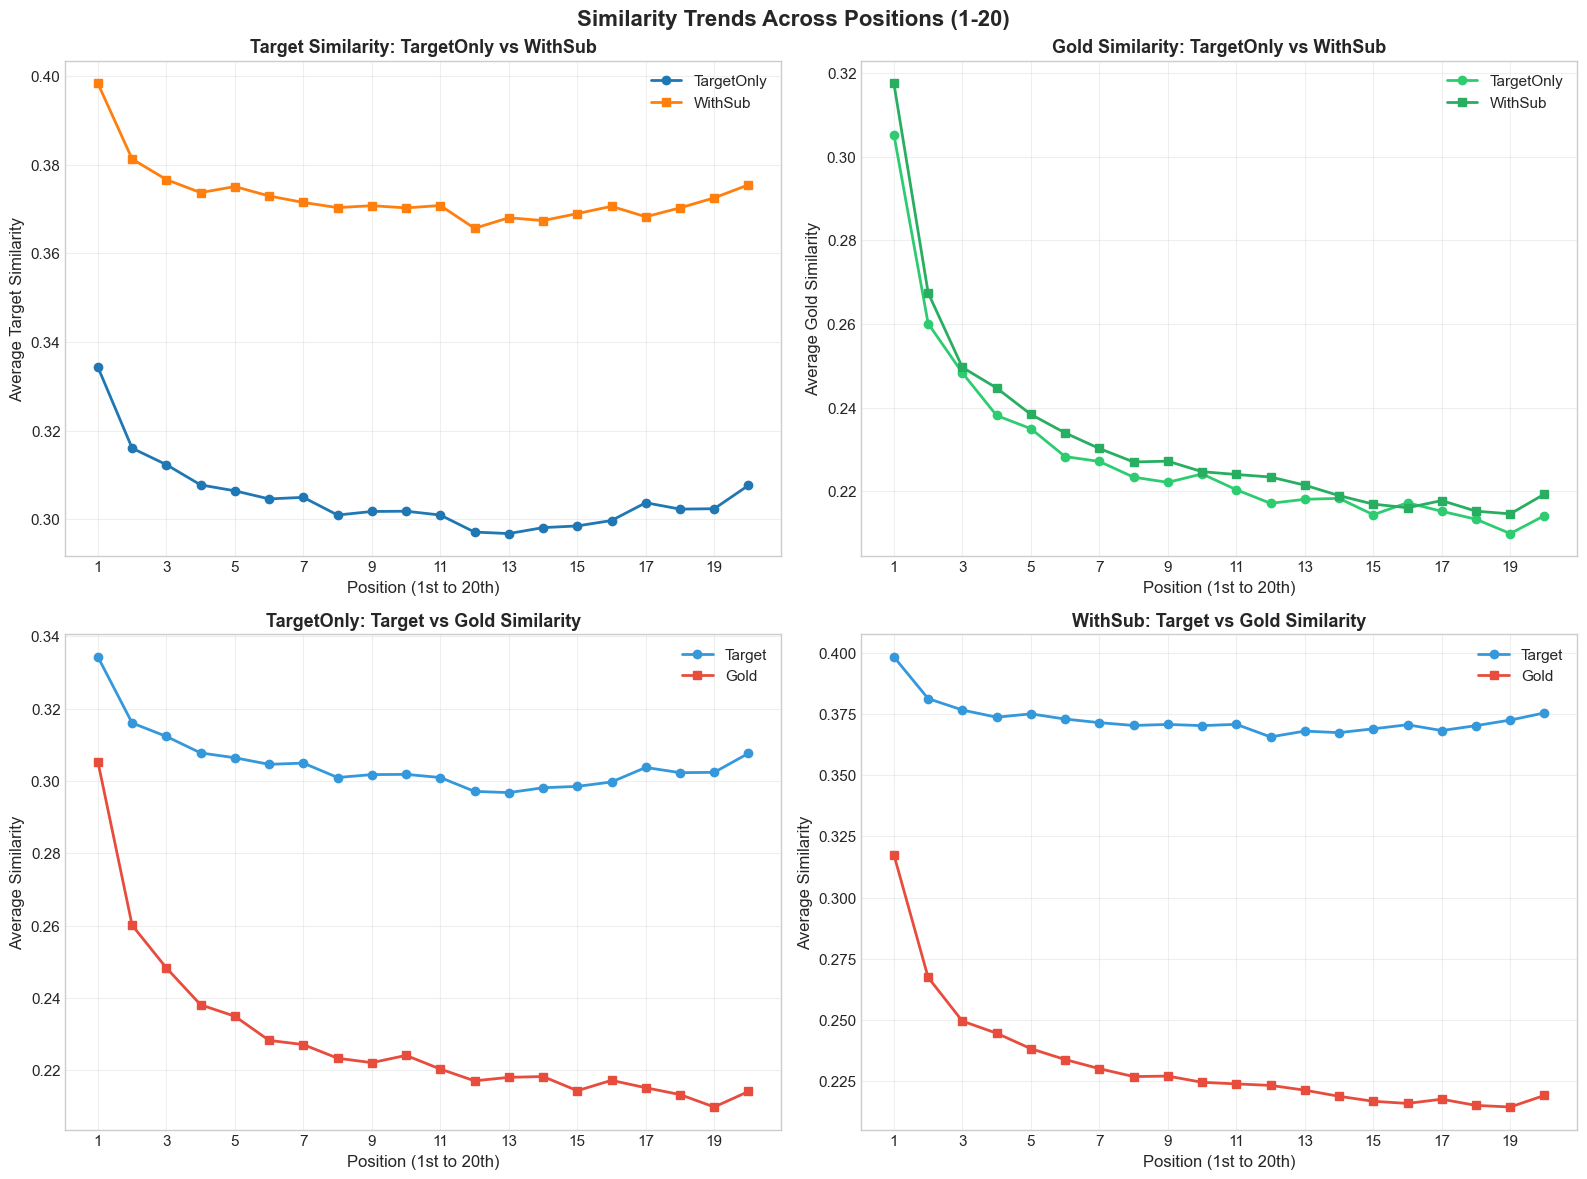

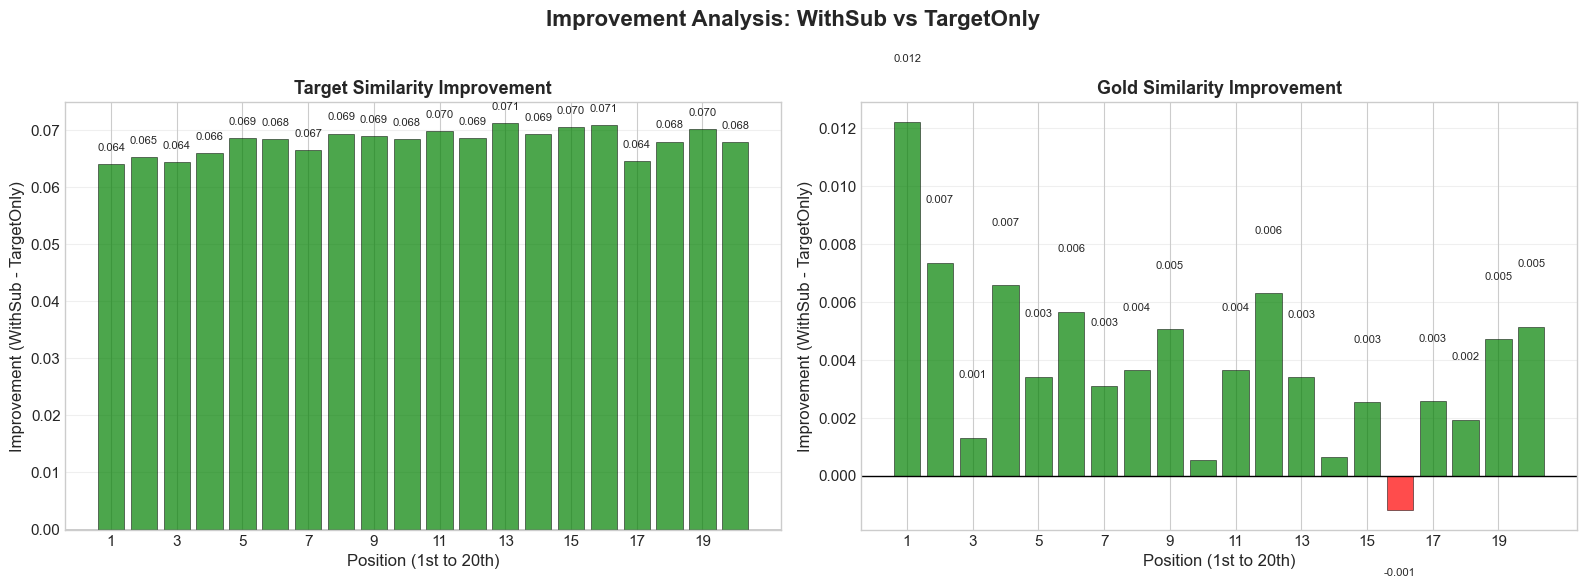

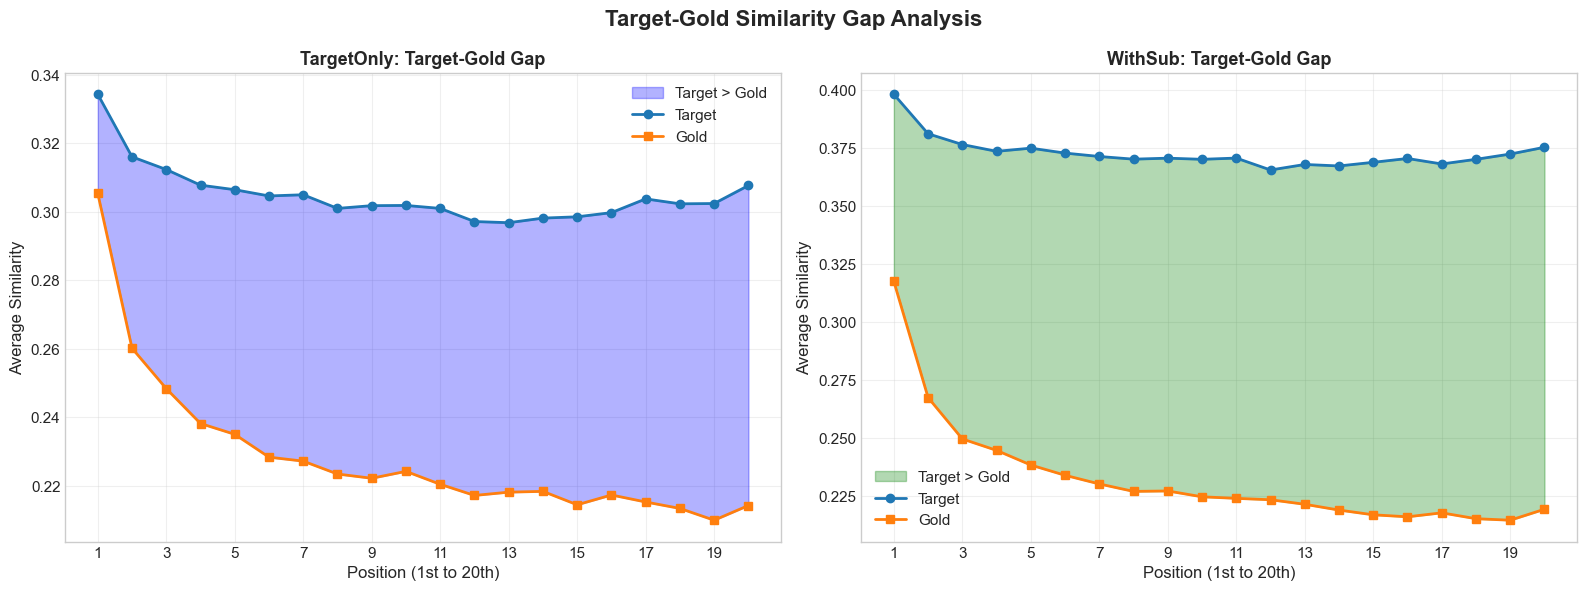

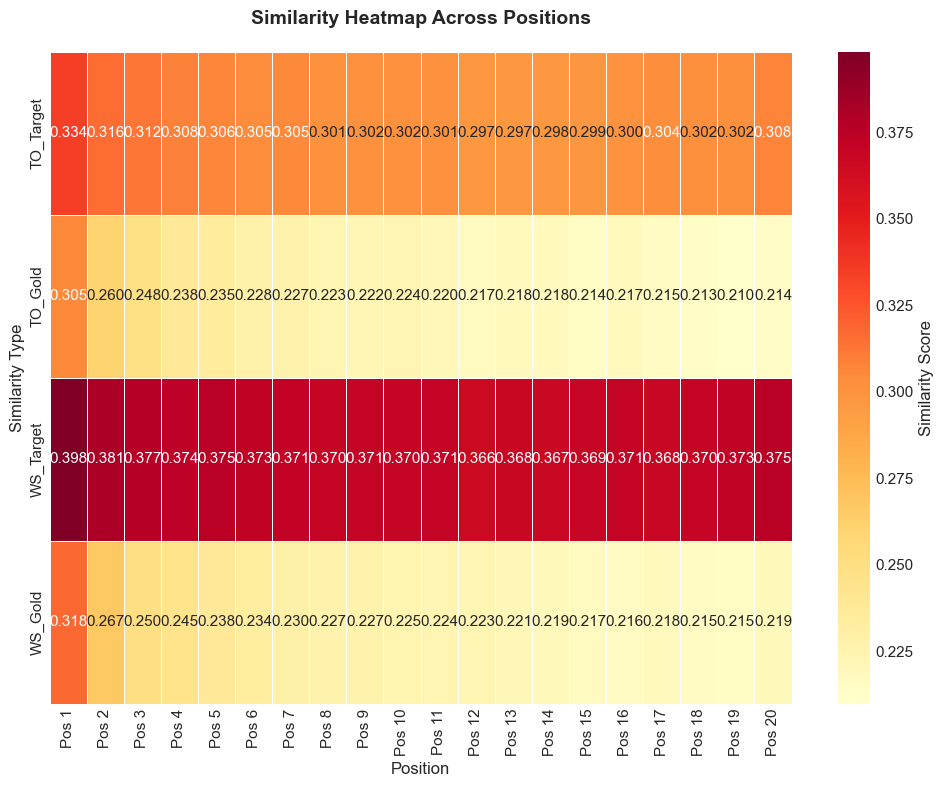

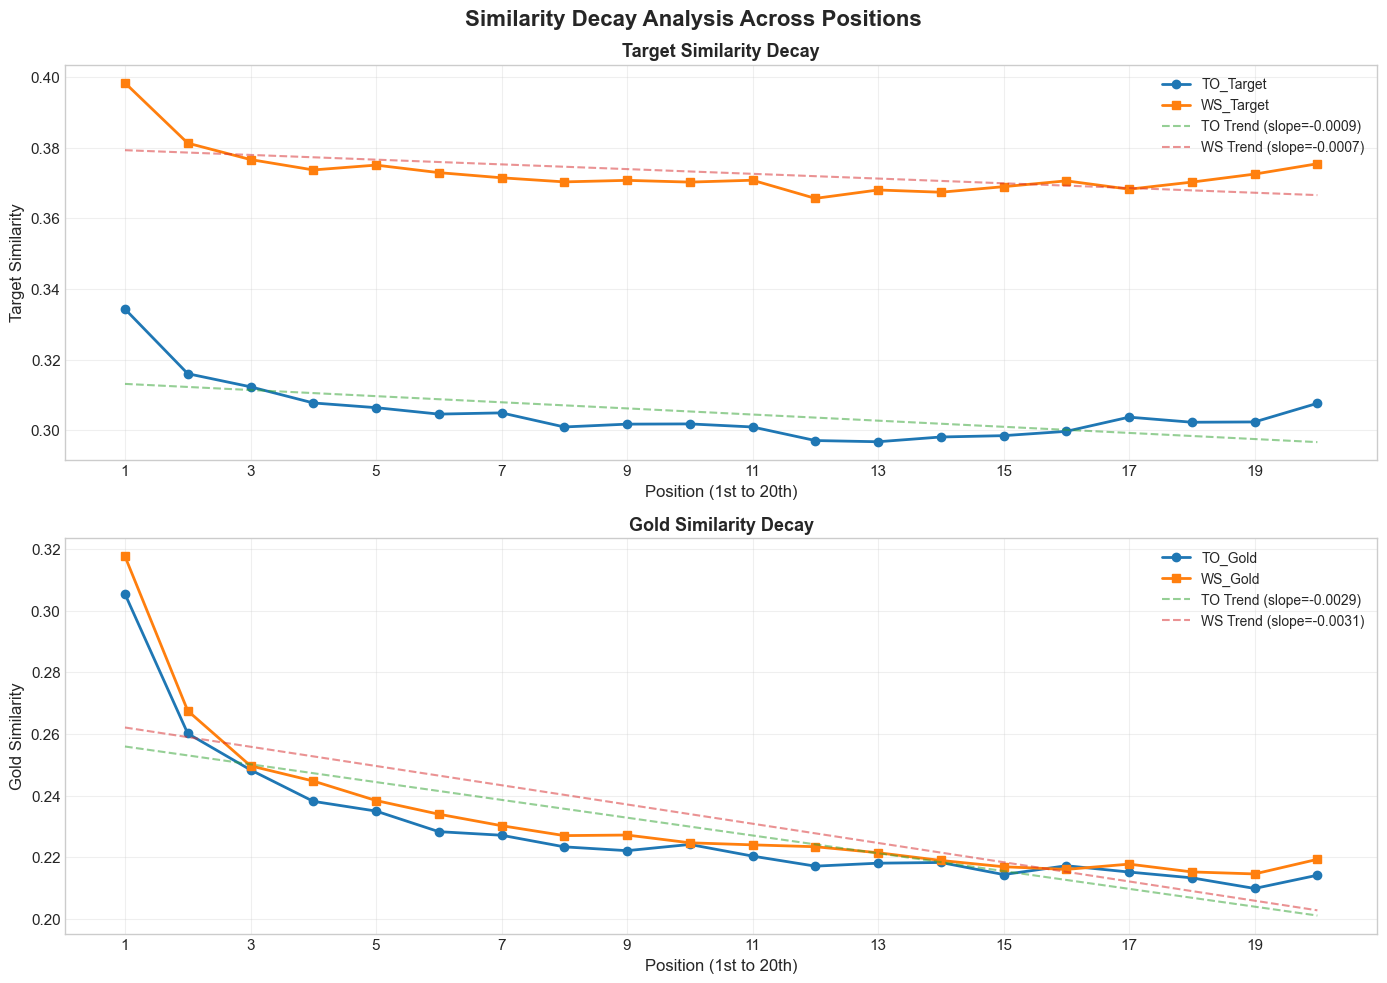


SUMMARY STATISTICS
Metric  TO_Target  TO_Gold  WS_Target  WS_Gold
  Mean   0.304927 0.228486   0.372920 0.232416
   Std   0.008482 0.022025   0.006968 0.024115
   Min   0.296798 0.209859   0.365637 0.214573
   Max   0.334325 0.305339   0.398298 0.317563
 Range   0.037527 0.095480   0.032661 0.102990


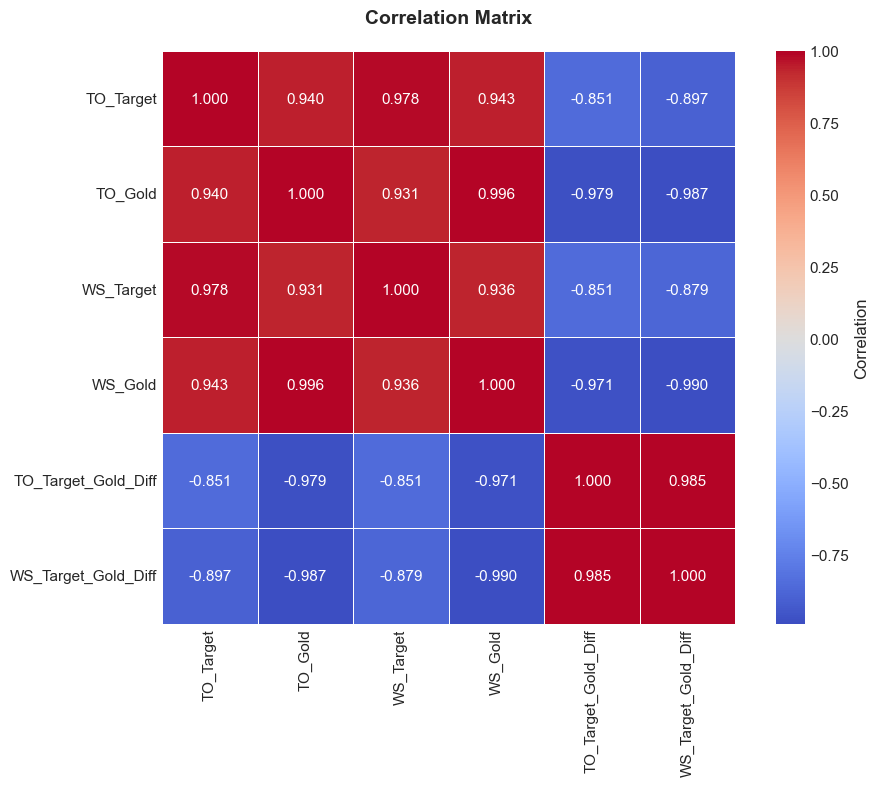


KEY INSIGHTS
1. Average Target Similarity Improvement: 0.0680
2. Average Gold Similarity Improvement: 0.0039
3. Target Similarity Range (TO): 0.0375
4. Target Similarity Range (WS): 0.0327
5. Gold Similarity Range (TO): 0.0955
6. Gold Similarity Range (WS): 0.1030
7. Average Target-Gold Gap (TO): 0.0764
8. Average Target-Gold Gap (WS): 0.1405


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv('position_similarity_comparison.csv')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# 1. SIMILARITY TRENDS ACROSS POSITIONS
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Similarity Trends Across Positions (1-20)', fontsize=16, fontweight='bold')

# 1a. Target Similarity Comparison
ax1 = axes[0, 0]
ax1.plot(df['Position'], df['TO_Target'], marker='o', label='TargetOnly', linewidth=2, markersize=6)
ax1.plot(df['Position'], df['WS_Target'], marker='s', label='WithSub', linewidth=2, markersize=6)
ax1.set_xlabel('Position (1st to 20th)', fontsize=12)
ax1.set_ylabel('Average Target Similarity', fontsize=12)
ax1.set_title('Target Similarity: TargetOnly vs WithSub', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, 21, 2))

# 1b. Gold Similarity Comparison
ax2 = axes[0, 1]
ax2.plot(df['Position'], df['TO_Gold'], marker='o', label='TargetOnly', linewidth=2, markersize=6, color='#2ecc71')
ax2.plot(df['Position'], df['WS_Gold'], marker='s', label='WithSub', linewidth=2, markersize=6, color='#27ae60')
ax2.set_xlabel('Position (1st to 20th)', fontsize=12)
ax2.set_ylabel('Average Gold Similarity', fontsize=12)
ax2.set_title('Gold Similarity: TargetOnly vs WithSub', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 21, 2))

# 1c. Target vs Gold for TargetOnly
ax3 = axes[1, 0]
ax3.plot(df['Position'], df['TO_Target'], marker='o', label='Target', linewidth=2, markersize=6, color='#3498db')
ax3.plot(df['Position'], df['TO_Gold'], marker='s', label='Gold', linewidth=2, markersize=6, color='#e74c3c')
ax3.set_xlabel('Position (1st to 20th)', fontsize=12)
ax3.set_ylabel('Average Similarity', fontsize=12)
ax3.set_title('TargetOnly: Target vs Gold Similarity', fontsize=13, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(range(1, 21, 2))

# 1d. Target vs Gold for WithSub
ax4 = axes[1, 1]
ax4.plot(df['Position'], df['WS_Target'], marker='o', label='Target', linewidth=2, markersize=6, color='#3498db')
ax4.plot(df['Position'], df['WS_Gold'], marker='s', label='Gold', linewidth=2, markersize=6, color='#e74c3c')
ax4.set_xlabel('Position (1st to 20th)', fontsize=12)
ax4.set_ylabel('Average Similarity', fontsize=12)
ax4.set_title('WithSub: Target vs Gold Similarity', fontsize=13, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)
ax4.set_xticks(range(1, 21, 2))

plt.tight_layout()
plt.savefig('similarity_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. IMPROVEMENT ANALYSIS (WithSub - TargetOnly)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Improvement Analysis: WithSub vs TargetOnly', fontsize=16, fontweight='bold')

# 2a. Target Improvement
ax1 = axes[0]
colors = ['green' if x > 0 else 'red' for x in df['Target_Diff_WS_TO']]
bars = ax1.bar(df['Position'], df['Target_Diff_WS_TO'], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel('Position (1st to 20th)', fontsize=12)
ax1.set_ylabel('Improvement (WithSub - TargetOnly)', fontsize=12)
ax1.set_title('Target Similarity Improvement', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(range(1, 21, 2))
# Add value labels on bars
for i, (pos, val) in enumerate(zip(df['Position'], df['Target_Diff_WS_TO'])):
    if abs(val) > 0.001:
        ax1.text(pos, val + (0.002 if val > 0 else -0.002), f'{val:.3f}', 
                ha='center', va='bottom' if val > 0 else 'top', fontsize=8)

# 2b. Gold Improvement
ax2 = axes[1]
colors = ['green' if x > 0 else 'red' for x in df['Gold_Diff_WS_TO']]
bars = ax2.bar(df['Position'], df['Gold_Diff_WS_TO'], color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Position (1st to 20th)', fontsize=12)
ax2.set_ylabel('Improvement (WithSub - TargetOnly)', fontsize=12)
ax2.set_title('Gold Similarity Improvement', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(range(1, 21, 2))
# Add value labels on bars
for i, (pos, val) in enumerate(zip(df['Position'], df['Gold_Diff_WS_TO'])):
    if abs(val) > 0.001:
        ax2.text(pos, val + (0.002 if val > 0 else -0.002), f'{val:.3f}', 
                ha='center', va='bottom' if val > 0 else 'top', fontsize=8)

plt.tight_layout()
plt.savefig('improvement_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. TARGET vs GOLD GAP ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Target-Gold Similarity Gap Analysis', fontsize=16, fontweight='bold')

# 3a. Gap for TargetOnly
ax1 = axes[0]
ax1.fill_between(df['Position'], df['TO_Target'], df['TO_Gold'], 
                 where=(df['TO_Target'] >= df['TO_Gold']), 
                 alpha=0.3, color='blue', label='Target > Gold')
ax1.plot(df['Position'], df['TO_Target'], marker='o', label='Target', linewidth=2, markersize=6)
ax1.plot(df['Position'], df['TO_Gold'], marker='s', label='Gold', linewidth=2, markersize=6)
ax1.set_xlabel('Position (1st to 20th)', fontsize=12)
ax1.set_ylabel('Average Similarity', fontsize=12)
ax1.set_title('TargetOnly: Target-Gold Gap', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, 21, 2))

# 3b. Gap for WithSub
ax2 = axes[1]
ax2.fill_between(df['Position'], df['WS_Target'], df['WS_Gold'], 
                 where=(df['WS_Target'] >= df['WS_Gold']), 
                 alpha=0.3, color='green', label='Target > Gold')
ax2.plot(df['Position'], df['WS_Target'], marker='o', label='Target', linewidth=2, markersize=6)
ax2.plot(df['Position'], df['WS_Gold'], marker='s', label='Gold', linewidth=2, markersize=6)
ax2.set_xlabel('Position (1st to 20th)', fontsize=12)
ax2.set_ylabel('Average Similarity', fontsize=12)
ax2.set_title('WithSub: Target-Gold Gap', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 21, 2))

plt.tight_layout()
plt.savefig('target_gold_gap.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. HEATMAP: Similarity Matrix
fig, ax = plt.subplots(figsize=(10, 8))
similarity_matrix = df[['TO_Target', 'TO_Gold', 'WS_Target', 'WS_Gold']].T
similarity_matrix.columns = [f'Pos {i}' for i in df['Position']]
similarity_matrix.index = ['TO_Target', 'TO_Gold', 'WS_Target', 'WS_Gold']

sns.heatmap(similarity_matrix, annot=True, fmt='.3f', cmap='YlOrRd', 
            cbar_kws={'label': 'Similarity Score'}, ax=ax, linewidths=0.5)
ax.set_title('Similarity Heatmap Across Positions', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Similarity Type', fontsize=12)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. DECAY ANALYSIS: How similarity changes across positions
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Similarity Decay Analysis Across Positions', fontsize=16, fontweight='bold')

# 5a. Target Similarity Decay
ax1 = axes[0]
ax1.plot(df['Position'], df['TO_Target'], marker='o', label='TO_Target', linewidth=2, markersize=6)
ax1.plot(df['Position'], df['WS_Target'], marker='s', label='WS_Target', linewidth=2, markersize=6)
# Add trend lines
z1 = np.polyfit(df['Position'], df['TO_Target'], 1)
p1 = np.poly1d(z1)
z2 = np.polyfit(df['Position'], df['WS_Target'], 1)
p2 = np.poly1d(z2)
ax1.plot(df['Position'], p1(df['Position']), "--", alpha=0.5, label=f'TO Trend (slope={z1[0]:.4f})')
ax1.plot(df['Position'], p2(df['Position']), "--", alpha=0.5, label=f'WS Trend (slope={z2[0]:.4f})')
ax1.set_xlabel('Position (1st to 20th)', fontsize=12)
ax1.set_ylabel('Target Similarity', fontsize=12)
ax1.set_title('Target Similarity Decay', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, 21, 2))

# 5b. Gold Similarity Decay
ax2 = axes[1]
ax2.plot(df['Position'], df['TO_Gold'], marker='o', label='TO_Gold', linewidth=2, markersize=6)
ax2.plot(df['Position'], df['WS_Gold'], marker='s', label='WS_Gold', linewidth=2, markersize=6)
# Add trend lines
z3 = np.polyfit(df['Position'], df['TO_Gold'], 1)
p3 = np.poly1d(z3)
z4 = np.polyfit(df['Position'], df['WS_Gold'], 1)
p4 = np.poly1d(z4)
ax2.plot(df['Position'], p3(df['Position']), "--", alpha=0.5, label=f'TO Trend (slope={z3[0]:.4f})')
ax2.plot(df['Position'], p4(df['Position']), "--", alpha=0.5, label=f'WS Trend (slope={z4[0]:.4f})')
ax2.set_xlabel('Position (1st to 20th)', fontsize=12)
ax2.set_ylabel('Gold Similarity', fontsize=12)
ax2.set_title('Gold Similarity Decay', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 21, 2))

plt.tight_layout()
plt.savefig('similarity_decay.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. SUMMARY STATISTICS TABLE
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

summary_stats = pd.DataFrame({
    'Metric': ['Mean', 'Std', 'Min', 'Max', 'Range'],
    'TO_Target': [df['TO_Target'].mean(), df['TO_Target'].std(), 
                  df['TO_Target'].min(), df['TO_Target'].max(), 
                  df['TO_Target'].max() - df['TO_Target'].min()],
    'TO_Gold': [df['TO_Gold'].mean(), df['TO_Gold'].std(), 
                df['TO_Gold'].min(), df['TO_Gold'].max(), 
                df['TO_Gold'].max() - df['TO_Gold'].min()],
    'WS_Target': [df['WS_Target'].mean(), df['WS_Target'].std(), 
                  df['WS_Target'].min(), df['WS_Target'].max(), 
                  df['WS_Target'].max() - df['WS_Target'].min()],
    'WS_Gold': [df['WS_Gold'].mean(), df['WS_Gold'].std(), 
                df['WS_Gold'].min(), df['WS_Gold'].max(), 
                df['WS_Gold'].max() - df['WS_Gold'].min()],
})

print(summary_stats.to_string(index=False))

# 7. CORRELATION ANALYSIS
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[['TO_Target', 'TO_Gold', 'WS_Target', 'WS_Gold', 
                  'TO_Target_Gold_Diff', 'WS_Target_Gold_Diff']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("KEY INSIGHTS")
print("="*80)
print(f"1. Average Target Similarity Improvement: {df['Target_Diff_WS_TO'].mean():.4f}")
print(f"2. Average Gold Similarity Improvement: {df['Gold_Diff_WS_TO'].mean():.4f}")
print(f"3. Target Similarity Range (TO): {df['TO_Target'].max() - df['TO_Target'].min():.4f}")
print(f"4. Target Similarity Range (WS): {df['WS_Target'].max() - df['WS_Target'].min():.4f}")
print(f"5. Gold Similarity Range (TO): {df['TO_Gold'].max() - df['TO_Gold'].min():.4f}")
print(f"6. Gold Similarity Range (WS): {df['WS_Gold'].max() - df['WS_Gold'].min():.4f}")
print(f"7. Average Target-Gold Gap (TO): {df['TO_Target_Gold_Diff'].mean():.4f}")
print(f"8. Average Target-Gold Gap (WS): {df['WS_Target_Gold_Diff'].mean():.4f}")

## LLM-reranker Visualizations

In [1]:
# =============================================================================
# LLM-RERANKER: Load rerank results + extract judge averages (baseline/embedding/rerank)
# =============================================================================

import pandas as pd
import numpy as np
import json
from pathlib import Path

RESULTS_DIR = Path('results')
OUTPUT_DIR = RESULTS_DIR / 'visualizations'
OUTPUT_DIR.mkdir(exist_ok=True)

# Load reranker result files
_df_to_r = pd.read_csv(RESULTS_DIR / 'all_results_targetonly_rerank.csv')
_df_ws_r = pd.read_csv(RESULTS_DIR / 'all_results_withsub_rerank.csv')

df_rerank = pd.concat([_df_to_r, _df_ws_r], ignore_index=True)

print(f"Loaded rerank records: targetonly={len(_df_to_r)}, withsub={len(_df_ws_r)}, total={len(df_rerank)}")
print(f"Modes: {sorted(df_rerank['mode'].dropna().unique().tolist())}")
print(f"Models: {df_rerank['model'].nunique()} - {sorted(df_rerank['model'].dropna().unique().tolist())}")

# -----------------------------------------------------------------------------
# Parse judge JSON and extract average score
# -----------------------------------------------------------------------------

def _safe_json(x):
    if pd.isna(x):
        return {}
    if isinstance(x, dict):
        return x
    try:
        return json.loads(x)
    except Exception:
        return {}

for col in ['judge_baseline', 'judge_embedding', 'judge_rerank']:
    if col in df_rerank.columns:
        df_rerank[col + '_parsed'] = df_rerank[col].apply(_safe_json)
    else:
        df_rerank[col + '_parsed'] = [{}] * len(df_rerank)

judge_map = {
    'Baseline': 'judge_baseline_parsed',
    'Embedding': 'judge_embedding_parsed',
    'Reranker': 'judge_rerank_parsed',
}

for method, parsed_col in judge_map.items():
    df_rerank[f'judge_{method.lower()}_avg'] = df_rerank[parsed_col].apply(
        lambda d: d.get('average', np.nan) if isinstance(d, dict) else np.nan
    )

# Long-form table for plotting
_long_parts = []
for method in ['Baseline', 'Embedding', 'Reranker']:
    _long_parts.append(
        df_rerank[['model', 'mode', f'judge_{method.lower()}_avg']]
        .rename(columns={f'judge_{method.lower()}_avg': 'judge_avg'})
        .assign(method=method)
    )

df_rerank_long = pd.concat(_long_parts, ignore_index=True)

# Aggregate mean judge score by model x mode x method
rerank_summary = (
    df_rerank_long
    .groupby(['mode', 'model', 'method'], dropna=False)['judge_avg']
    .mean()
    .reset_index()
)

print("\nRerank judge averages extracted.")
print(rerank_summary.head(10).to_string(index=False))


Loaded rerank records: targetonly=3737, withsub=3850, total=7587
Modes: ['targetonly', 'withsub']
Models: 12 - ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct', 'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct', 'qwen3-14b', 'qwen3-32b']

Rerank judge averages extracted.
      mode                 model    method  judge_avg
targetonly           deepseek-r1  Baseline   2.695950
targetonly           deepseek-r1 Embedding   2.470374
targetonly           deepseek-r1  Reranker   2.789782
targetonly gemini-2.5-flash-lite  Baseline   2.689907
targetonly gemini-2.5-flash-lite Embedding   2.382523
targetonly gemini-2.5-flash-lite  Reranker   2.861589
targetonly          gpt-4.1-mini  Baseline   2.636636
targetonly          gpt-4.1-mini Embedding   2.292056
targetonly          gpt-4.1-mini  Reranker   2.813676
targetonly          gpt-4.1-nano  Baseline   2.479907


In [2]:
# =============================================================================
# LLM-RERANKER: Faceted plots (per mode) — baseline vs embedding vs reranker
# =============================================================================

# (Duplicate plotting cell removed; use the next cell which also prints per-mode rankings.)



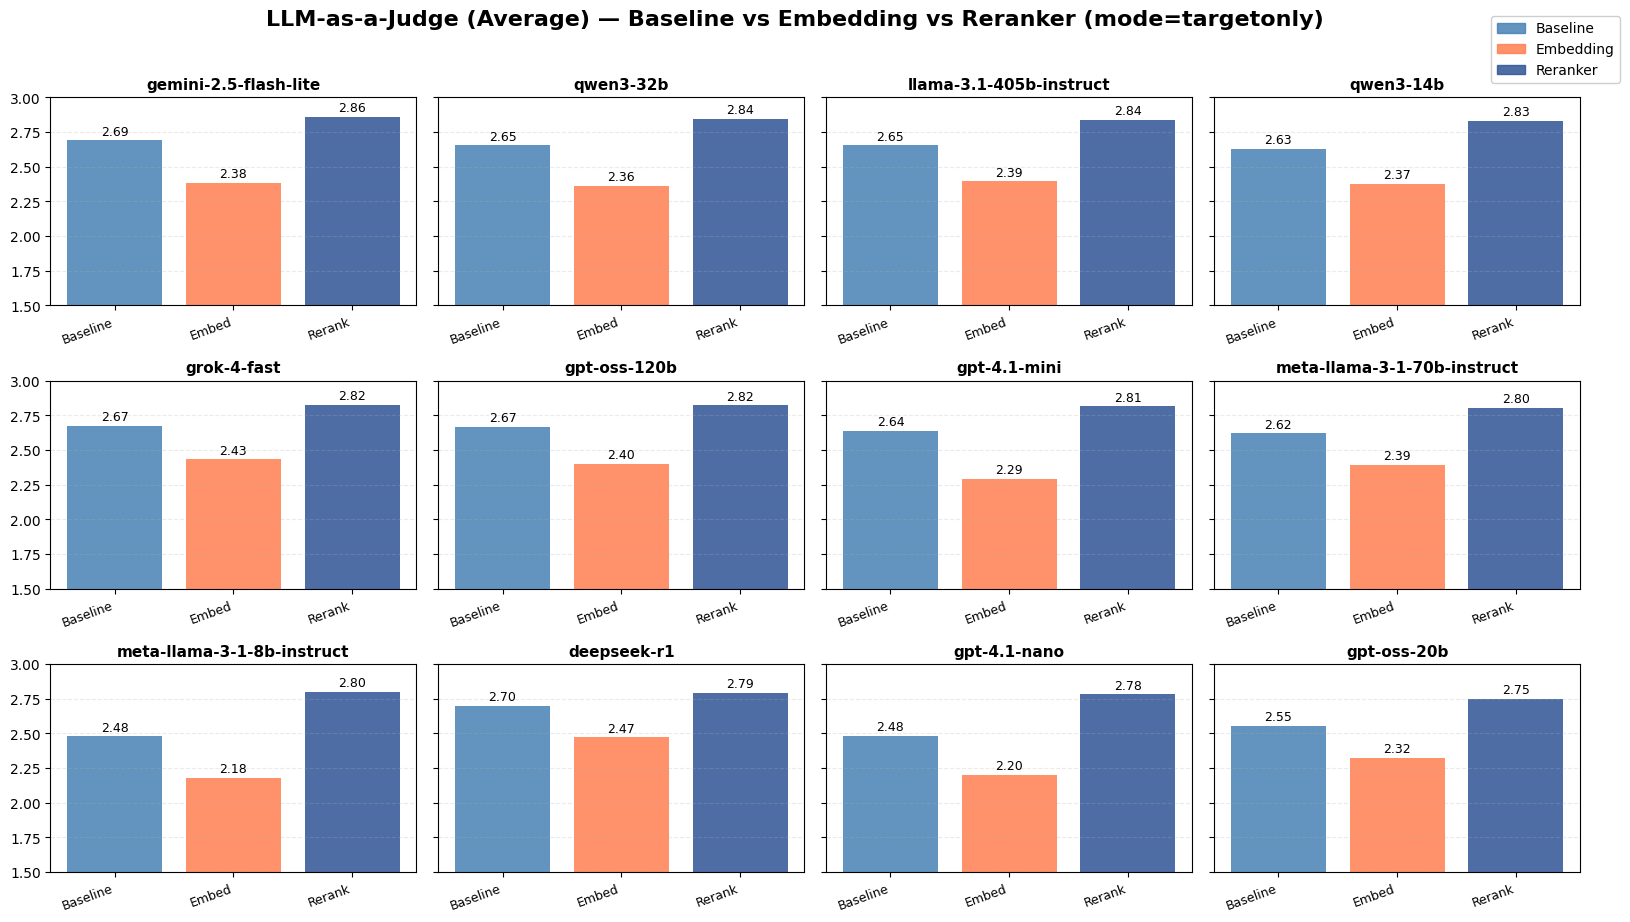

Saved: results\visualizations\figure_rerank_judge_avg_by_model_targetonly.png


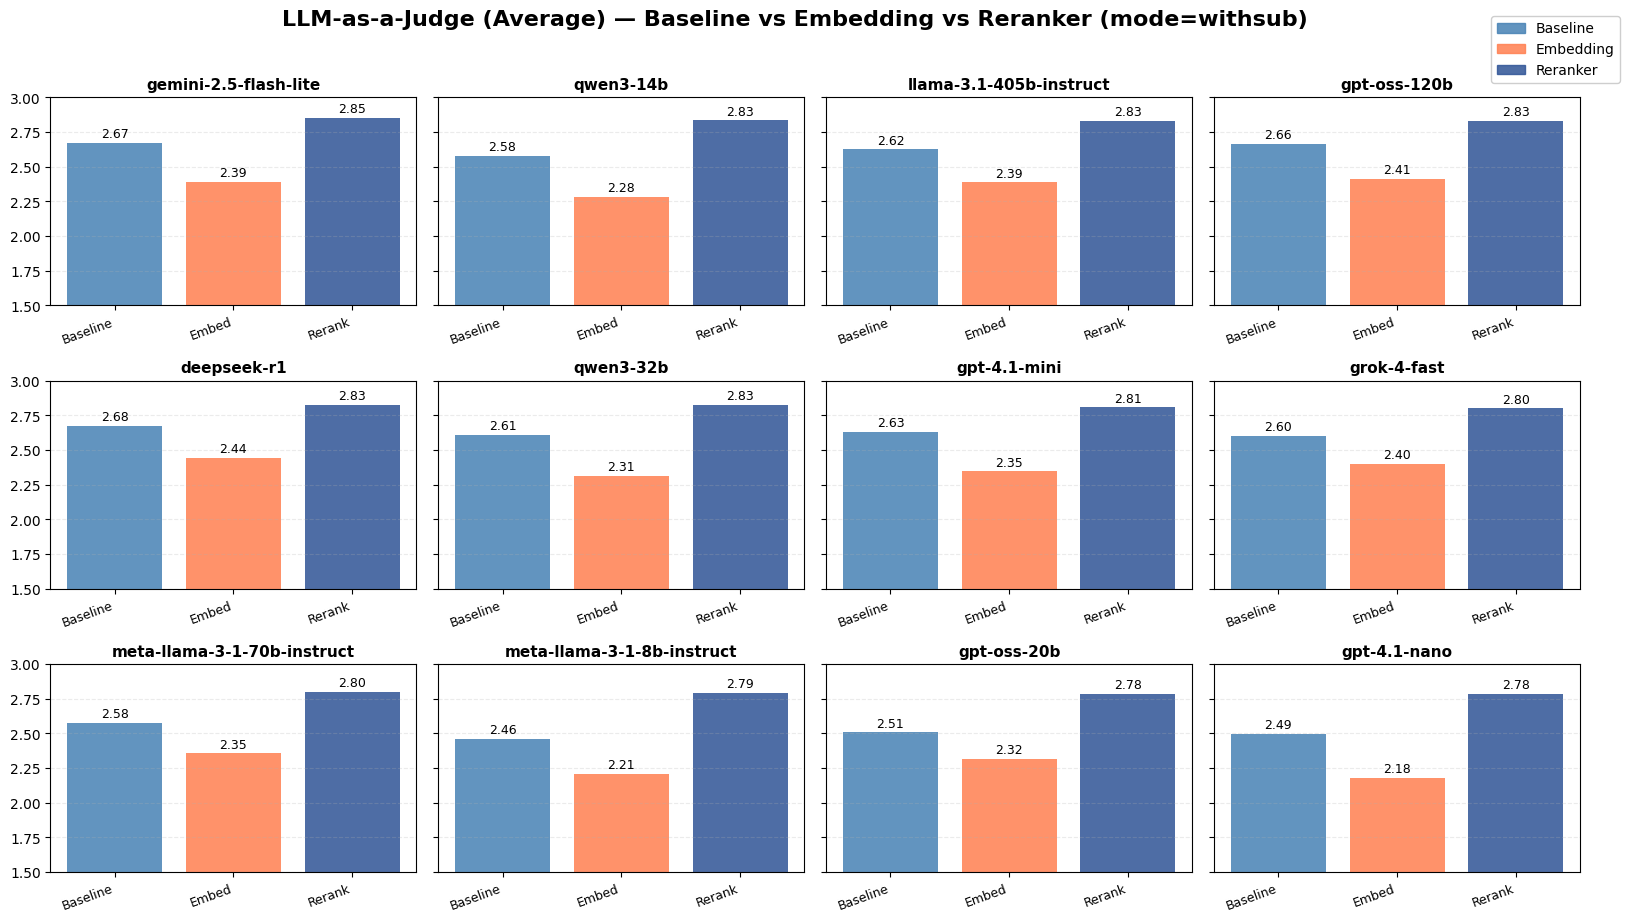

Saved: results\visualizations\figure_rerank_judge_avg_by_model_withsub.png

MODEL RANKING (mode=targetonly) — sorted by Reranker
                      model                model_abbrev  Baseline  Embedding  Reranker
      gemini-2.5-flash-lite       gemini-2.5-flash-lite     2.690      2.383     2.862
                  qwen3-32b                   qwen3-32b     2.653      2.363     2.843
    llama-3.1-405b-instruct     llama-3.1-405b-instruct     2.653      2.394     2.839
                  qwen3-14b                   qwen3-14b     2.630      2.374     2.828
                grok-4-fast                 grok-4-fast     2.671      2.432     2.823
               gpt-oss-120b                gpt-oss-120b     2.667      2.401     2.822
               gpt-4.1-mini                gpt-4.1-mini     2.637      2.292     2.814
meta-llama-3-1-70b-instruct meta-llama-3-1-70b-instruct     2.620      2.390     2.802
 meta-llama-3-1-8b-instruct  meta-llama-3-1-8b-instruct     2.478      2.176     2.799
 

In [3]:
# =============================================================================
# LLM-RERANKER: Faceted plots (per mode) — baseline vs embedding vs reranker
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure basic globals exist (so this cell can run independently)
if 'COLORS' not in globals() or not isinstance(COLORS, dict):
    COLORS = {
        'primary': '#4682B4',
        'secondary': '#FF7F50',
        'dark': '#2F5496',
    }

if 'OUTPUT_DIR' not in globals():
    RESULTS_DIR = Path('results')
    OUTPUT_DIR = RESULTS_DIR / 'visualizations'
    OUTPUT_DIR.mkdir(exist_ok=True)

if 'df_rerank' not in globals():
    _df_to_r = pd.read_csv(Path('results') / 'all_results_targetonly_rerank.csv')
    _df_ws_r = pd.read_csv(Path('results') / 'all_results_withsub_rerank.csv')
    df_rerank = pd.concat([_df_to_r, _df_ws_r], ignore_index=True)

# Safety: if rerank_summary isn't available, re-derive from df_rerank
if 'rerank_summary' not in globals():
    _long_parts = []
    for method in ['Baseline', 'Embedding', 'Reranker']:
        _long_parts.append(
            df_rerank[['model', 'mode', f'judge_{method.lower()}_avg']]
            .rename(columns={f'judge_{method.lower()}_avg': 'judge_avg'})
            .assign(method=method)
        )
    df_rerank_long = pd.concat(_long_parts, ignore_index=True)
    rerank_summary = (
        df_rerank_long
        .groupby(['mode', 'model', 'method'], dropna=False)['judge_avg']
        .mean()
        .reset_index()
    )

METHOD_ORDER = ['Baseline', 'Embedding', 'Reranker']
METHOD_TICKS = ['Baseline', 'Embed', 'Rerank']
METHOD_COLORS = {
    'Baseline': COLORS.get('primary', '#4682B4') if isinstance(COLORS, dict) else '#4682B4',
    'Embedding': COLORS.get('secondary', '#FF7F50') if isinstance(COLORS, dict) else '#FF7F50',
    'Reranker': COLORS.get('dark', '#2F5496') if isinstance(COLORS, dict) else '#2F5496',
}


def plot_rerank_mode(mode: str, ncols: int = 4):
    mode_df = rerank_summary[rerank_summary['mode'] == mode].copy()

    pivot = mode_df.pivot_table(
        index='model',
        columns='method',
        values='judge_avg',
        aggfunc='mean'
    ).reindex(columns=METHOD_ORDER)

    sort_col = 'Reranker' if 'Reranker' in pivot.columns else METHOD_ORDER[0]
    pivot = pivot.sort_values(sort_col, ascending=False)

    models = pivot.index.tolist()
    n = len(models)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.0 * ncols, 3.0 * nrows),
        sharey=True
    )
    axes = np.array(axes).reshape(-1)

    for i, model in enumerate(models):
        ax = axes[i]
        vals = pivot.loc[model].values

        x = np.arange(len(METHOD_ORDER))
        ax.bar(
            x,
            vals,
            color=[METHOD_COLORS[m] for m in METHOD_ORDER],
            alpha=0.85
        )

        try:
            title = get_model_abbrev(model)
        except Exception:
            title = model

        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(METHOD_TICKS, rotation=20, ha='right', fontsize=9)
        ax.set_ylim(1.5, 3.0)
        ax.grid(axis='y', alpha=0.25, linestyle='--')

        for xi, v in enumerate(vals):
            if pd.notna(v):
                ax.text(xi, v + 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(
        f"LLM-as-a-Judge (Average) — Baseline vs Embedding vs Reranker (mode={mode})",
        fontsize=16,
        fontweight='bold',
        y=1.02
    )

    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color=METHOD_COLORS[m], alpha=0.85)
        for m in METHOD_ORDER
    ]
    fig.legend(
        legend_handles,
        METHOD_ORDER,
        loc='upper right',
        bbox_to_anchor=(1.02, 1.02),
        framealpha=0.95
    )

    plt.tight_layout()
    out_path = OUTPUT_DIR / f"figure_rerank_judge_avg_by_model_{mode}.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

    print(f"Saved: {out_path}")
    return pivot


pivot_targetonly = plot_rerank_mode('targetonly')
pivot_withsub = plot_rerank_mode('withsub')

# =============================================================================
# RANKINGS: best model per mode (by reranker judge avg)
# =============================================================================

def print_rankings(pivot, mode: str, top_n: int = 12):
    rank_df = pivot.copy()
    rank_df = rank_df.reset_index().rename(columns={'index': 'model'})

    # Keep original model id for reproducibility, but show abbrev too
    try:
        rank_df['model_abbrev'] = rank_df['model'].apply(get_model_abbrev)
    except Exception:
        rank_df['model_abbrev'] = rank_df['model']

    sort_col = 'Reranker' if 'Reranker' in rank_df.columns else 'Baseline'
    rank_df = rank_df.sort_values(sort_col, ascending=False)

    cols = ['model', 'model_abbrev', 'Baseline', 'Embedding', 'Reranker']
    cols = [c for c in cols if c in rank_df.columns]

    print("\n" + "=" * 90)
    print(f"MODEL RANKING (mode={mode}) — sorted by {sort_col}")
    print("=" * 90)
    print(rank_df[cols].head(top_n).round(3).to_string(index=False))


print_rankings(pivot_targetonly, 'targetonly')
print_rankings(pivot_withsub, 'withsub')

